# 학생 건강 리스크 예측 — Kaggle Playground S6E7

수면·심박수·활동량 같은 생활 단서 13개로 학생의 건강 상태(fit / at-risk / unhealthy)를 예측하는 3-클래스 분류 대회다. 채점 지표는 balanced accuracy로, 클래스별 정답률(재현율)을 똑같은 비중으로 평균한다. 소수 클래스도 다수 클래스만큼 중요하게 본다.

**TL;DR — 최종 balanced accuracy ≈ 0.949 (공개 LB 실측)**
> β 보정(답 고르는 규칙 하나, §9에서 설명) 깔끔판 0.94923, 튜닝 포함 최고 0.94967. 둘 차이 +0.0004는 미미해 같은 값으로 본다.

- **점수를 가른 건 모델보다 답 고르는 규칙이었다.** 같은 XGBoost로, 예측 확률을 클래스 원래 비율로 나누는 결정 규칙(β 보정) 하나가 0.8796을 0.9494로 끌어올렸다(+0.0698, 같은 원핫 XGB — 원핫은 §3, XGB는 §6에서 설명). 모델 재학습 없이 확률에 나눗셈 한 번.
- **처음엔 기준을 잘못 잡아 헛다리를 짚었다.** 첫 모델이 정확도(accuracy) 96%라 좋아 보였지만 리더보드는 86%였다. 실력이 떨어진 게 아니라 검증에 쓴 기준(정확도)이 대회 채점 기준(balanced accuracy)과 달랐던 탓이다.
- **0.949 근처에서 멈췄다.** 7가지 기법(튜닝·앙상블·클래스별 β 등)을 실측하고 최다득표 스태킹 노트북과 대조했지만 전부 최종 점수엔 무영향이었다. 최고점 0.94967조차 튜닝의 성과가 아니라 노이즈 우위였다. 다만 공개 LB엔 우리 위로 758팀이 있어(0.95를 넘긴 팀만 406, 1등 0.952) 데이터 천장은 아니다 — 우리 도구 범위에선 ~0.949가 실용적 정체 구간이고, 그 위는 더 나은 모델의 몫이라 보고 멈췄다.
- **끝으로 "이 모델로 뭘 할 것인가"(액션 플랜)를 실측으로 설계했다.** 배포할 것은 모델이 아니라 모델이 찾아낸 것들이다 — 선별력 대부분을 담은 설문 3문항(0.5h 응답 해상도로 0.938 — 모델 0.9494의 98.7%), 상담 예산별 커버리지 곡선(모델 기준 상위 10% 호출 → 위험군 93%, 설문만으론 87%), 규모가 붙은 프로그램 표.

## 1. 준비 — 데이터 불러오기

`pandas`로 train.csv를 읽는다. 뒤에 나오는 모든 무작위 단계(데이터 나누기, 모델 학습)는 `random_state=42`로 고정해 다시 실행해도 같은 결과가 나오게 했다.

In [1]:
import pandas as pd

train = pd.read_csv("train.csv")
print(train.shape)
train.head()

(690088, 15)


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 2. 데이터 살펴보기 — 결측치, 그리고 합성 데이터?

69만 행, 15컬럼(id + 정답 health_condition + 단서 13개). 먼저 빈 칸(결측치)이 얼마나 있는지부터 확인한다.

In [2]:
train.isnull().sum()

id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64

컬럼이 몇 개 없으니 결측치도 적을 거라 예상했는데 빗나갔다. id만 빼고 모든 컬럼에 결측치가 있다(1~12%). 컬럼 수와 결측치 양은 사실 관계가 없다. 결측치는 데이터를 모을 때 컬럼 하나하나에서 독립적으로 생기기 때문이다.

빈 칸이 하나라도 있는 행을 통째로 지우면(dropna) 얼마나 남을까. 지우기 전에 예측해봤다. 13개 컬럼 각각이 독립적으로 빠질 확률이 있으니 한 행이 13개 전부 안 빠질 확률은 곱셈으로 급격히 작아진다는 논리로 거의 0에 가까울 거라 봤다.

In [3]:
# dropna() = 빈 칸이 하나라도 있는 행을 통째로 삭제
train_dropna = train.dropna()
print(len(train), "->", len(train_dropna))
print(round(len(train_dropna) / len(train) * 100, 1), "% 남음")

690088 -> 349623
50.7 % 남음


실제로는 50%가 남았다. 논리의 방향(많이 준다)은 맞았지만 크기는 과했던 예측이다. 그래도 절반을 그냥 버리는 건 손실이 커서 지우는 대신 빈 칸을 채우는 쪽(대체/imputation)으로 방향을 잡았다.

In [4]:
# 글자로 된(범주형) 단서들 - 각각 어떤 값이 몇 개씩 있는지
# dropna=False로 하면 빈 칸(NaN) 개수도 같이 보여줌
categorical_cols = ["diet_type", "stress_level", "sleep_quality", "physical_activity_level", "smoking_alcohol", "gender"]
for col in categorical_cols:
    print(train[col].value_counts(dropna=False))
    print()

diet_type
veg         231432
balanced    226888
non-veg     224867
NaN           6901
Name: count, dtype: int64

stress_level
medium    261819
high      177750
low       167708
NaN        82811
Name: count, dtype: int64

sleep_quality
average    213948
poor       212166
good       205643
NaN         58331
Name: count, dtype: int64

physical_activity_level
moderate     221041
sedentary    219784
active       212642
NaN           36621
Name: count, dtype: int64

smoking_alcohol
yes           223730
no            219791
occasional    217985
NaN            28582
Name: count, dtype: int64

gender
male      237756
female    224016
other     206943
NaN        21373
Name: count, dtype: int64



### 정말 3등분인가를 검정

위에서 diet_type이 33.9 / 33.2 / 32.9로 거의 3등분인 걸 확인했다.

카이제곱 적합도 검정(chi-square goodness-of-fit)은 관측 분포가 완벽한 3등분(각 1/3)에서 얼마나 벗어났는지를 측정한다. 두 값을 준다. **p값**은 이 차이가 우연인지, 함께 계산하는 **효과크기 Cohen's w**는 차이가 얼마나 큰지를 말해준다.

In [5]:
# 카이제곱 적합도 검정 + 효과크기(Cohen's w) — 6개 범주형이 얼마나 "완벽한 3등분"에 가까운가
from scipy.stats import chisquare
import numpy as np

rows = []
for col in categorical_cols:
    vc = train[col].value_counts()               # NaN 제외한 실제 응답만
    n, k = vc.sum(), len(vc)
    chi2, p = chisquare(vc.values, [n / k] * k)   # 기준 = 완벽한 균등(각 n/k)
    w = np.sqrt(chi2 / n)                         # Cohen's w = sqrt(χ²/N), 표본크기에 안 흔들림
    rows.append({"컬럼": col, "χ²": round(chi2), "p값": p, "Cohen_w": round(w, 3)})

chi_table = pd.DataFrame(rows).sort_values("Cohen_w").reset_index(drop=True)  # w 작은 순 = 균등한 순
chi_table

,컬럼,χ²,p값,Cohen_w
0,smoking_alcohol,78,1.004188e-17,0.011
1,diet_type,99,2.754846e-22,0.012
2,sleep_quality,182,3.767268e-40,0.017
3,physical_activity_level,188,1.211718e-41,0.017
4,gender,2138,0.000000e+00,0.057
5,stress_level,26389,0.000000e+00,0.208


### 카이제곱이 말해준 것 — 유의미(significant) ≠ 실제로 중요(meaningful)

p값 열을 먼저 보면 6개 전부 사실상 0이다. 69만 행이면 완벽한 1/3에서 0.몇 %만 벗어나도 우연이 아닌 것으로 잡혀서, p값으로는 어느 컬럼이 더 균등한지 구분조차 안 된다(0.001g까지 측정하는 초정밀 저울에 올리면 누구든 정확히 70kg은 아니라고 나오는 것과 같다). 큰 데이터에서 통계적으로 유의미(significant)한 것은 실제로 중요(meaningful)한 것과 전혀 다른 말이다.

답을 주는 건 **Cohen's w**다. 표본 크기에 안 흔들리고 실제로 얼마나 벗어났는지만 측정.

- **5개 컬럼(w 0.011~0.057)**: 거의 완벽하게 균등하다. 진짜 사람 데이터라면 이렇게 깔끔할 수 없으니 합성 신호다.
- **stress_level(w 0.208)**: 혼자 뚜렷이 치우침(43 / 29 / 28%). 눈으로 제일 치우쳐 보인 걸 숫자가 확증했다.

단, 정직하게 보면 저 균등한 5개도 완벽하게 1/3은 아니다. 순수 무작위라도 카이제곱은 0이 아니라 평균 2쯤 나오는데(값 종류가 3개라 자유도가 2), diet_type은 99(약 50배)다. 미세하지만 진짜 치우침이 있어서 "정확히 3등분"이라는 표현 자체가 살짝 과장이고, 카이제곱만으로는 합성을 증명하지 못한다(현실 데이터도 우연히 균등할 수 있으니까). 진짜 지문은 셋의 조합이다. ① 근-균등(w≈0.01), ② gender '기타' 31%라는 인구학적으로 불가능한 비율, ③ step_count의 하드 클리핑(뒤에서 확인). 검정은 그중 ①만 뒷받침한다.

전처리로 넘어가며 이 결과를 사용한다. 카테고리가 이렇게 균등하면 결측치를 최빈값으로 채워도 한쪽으로 쏠리는 편향이 우려보다 작다.

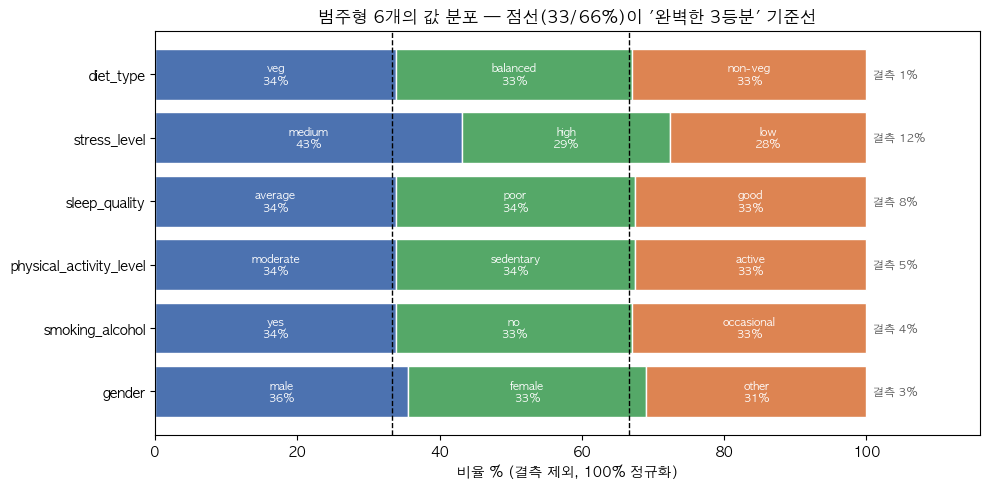

In [6]:
# 3등분 지문을 그림으로 — 범주형 6개의 값 분포 (결측 제외, 100% 정규화)
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"   # 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

slot_colors = ["#4C72B0", "#55A868", "#DD8452"]   # 가장 흔한 값 / 2번째 / 3번째
cols_plot = categorical_cols[::-1]                # 위->아래 보기 좋게 뒤집기

fig, ax = plt.subplots(figsize=(10, 5))
for y, col in enumerate(cols_plot):
    vc = train[col].value_counts().sort_values(ascending=False)   # 결측 제외, 빈도 내림차순
    left = 0
    for j, (name, ct) in enumerate(vc.items()):
        pct = ct / vc.sum() * 100
        ax.barh(y, pct, left=left, color=slot_colors[j], edgecolor="white")
        if pct > 7:
            ax.text(left + pct / 2, y, f"{name}\n{pct:.0f}%", ha="center", va="center",
                    color="white", fontsize=8)
        left += pct
    ax.text(101, y, f"결측 {train[col].isna().mean() * 100:.0f}%", va="center", fontsize=8, color="#555")

ax.axvline(33.33, color="black", ls="--", lw=1)   # '완벽한 3등분' 기준선
ax.axvline(66.67, color="black", ls="--", lw=1)
ax.set_yticks(range(len(cols_plot))); ax.set_yticklabels(cols_plot)
ax.set_xlim(0, 116); ax.set_xlabel("비율 % (결측 제외, 100% 정규화)")
ax.set_title("범주형 6개의 값 분포 — 점선(33/66%)이 '완벽한 3등분' 기준선")
plt.tight_layout(); plt.show()

위 5개 막대는 세그먼트 경계가 점선(33/66%)에 거의 붙어 있는데 stress_level만 43/29/28로 확 어긋난다. 앞의 Cohen's w(0.208)가 그림으로 그대로 보인다. 오른쪽 결측 %를 보면 stress_level이 12%로 결측도 제일 많다(분포·결측 둘 다 튀는 컬럼).

In [7]:
# 숫자로 된 단서들 - 평균/최소/최대 등 요약 통계
# .T = 표를 뒤집어서(행<->열) 컬럼이 잘리지 않고 다 보이게
numeric_cols = ["sleep_duration", "heart_rate", "bmi", "calorie_expenditure", "step_count", "exercise_duration", "water_intake"]
train[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,6.16,6.99,7.81,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,69.40,75.10,80.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,21.32,22.99,24.66,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,2053.00,2241.00,2456.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,5389.00,8856.00,12114.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,29.20,39.40,49.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,1.84,2.17,2.50,4.72


### 극단값 판정 — heart_rate·step_count의 인위적 범위 제한

heart_rate 최솟값 50을 처음엔 3σ(평균에서 표준편차 3배 밖 = 통계에서 '아주 드문 극단값'의 관례선) 아래라 운동선수급으로 넘겼는데, step_count와 같은 방식(경계에서 값이 끊기나)으로 다시 봤다.

**heart_rate:** 50 미만이 0개다(50.0이 87개, 그 아래 전무). 진짜라면 엘리트 선수는 40대까지 내려가는데 50에서 끊긴다. 하한 50이 인위적으로 고정된 것이다. 3σ가 아니라 경계였다(상한 107.7은 한 개뿐이라 느슨). 분포 자체는 매끈하다(고유값 537).

**step_count:** 1000 미만 0개(하한 고정), 최댓값 정확히 14999(상한 고정). 상하한이 인위적으로 잘렸지만 그 바로 안쪽은 오히려 드물다.

**정정:** 처음엔 15000 근처가 평범 구간의 5~10배라 눌린 흔적으로 봤는데, 실측하니 그 5~10배 출렁임이 분포 전체에 널려 있다(중간 8000~8300도 옆칸이 0인데 그 옆은 2000+). step_count는 어중간한 정수값이 반복되는 이산화 분포다(12182가 817번). 15000만 특별한 게 아니다.

heart_rate·step_count 모두 상하한이 인위적으로 고정돼 있다. 단 이것만으로 합성을 단정하진 않는다. 진짜 근거는 뒤의 범주 3등분, gender '기타' 31%, 그리고 원본 실데이터로 생성된 Kaggle Playground라는 출처다.

### 그림으로 확인 — 정답 분포와 step_count의 상하한

정답 클래스 분포는 이 대회 전체를 관통하는 조건.


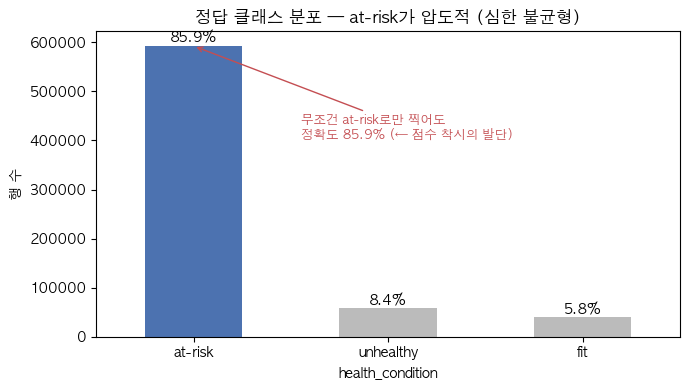

In [8]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "AppleGothic"   # 한글 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

counts = train["health_condition"].value_counts()
# 색으로 뜻을 싣는다: 다수 클래스(at-risk)만 강조, 나머지 둘은 회색
colors = ["#4C72B0" if c == "at-risk" else "#BBBBBB" for c in counts.index]
ax = counts.plot(kind="bar", color=colors, figsize=(7, 4), rot=0)
for i, v in enumerate(counts):
    ax.text(i, v, f"{v / len(train) * 100:.1f}%", ha="center", va="bottom")

# 이 그림의 핵심 판단을 화살표로 박아둔다 (뒤 서사의 발단)
ax.annotate("무조건 at-risk로만 찍어도\n정확도 85.9% (← 점수 착시의 발단)",
            xy=(0, counts.iloc[0]), xytext=(0.55, counts.iloc[0] * 0.72),
            fontsize=9, color="#C44E52", va="center",
            arrowprops=dict(arrowstyle="->", color="#C44E52"))
ax.set_title("정답 클래스 분포 — at-risk가 압도적 (심한 불균형)")
ax.set_ylabel("행 수")
plt.tight_layout()
plt.show()

at-risk 85.9 / unhealthy 8.4 / fit 5.8%. 무조건 at-risk라고만 찍어도 정확도 85.9%가 나오는 심한 불균형이다. 이 사실이 뒤에서 점수 착시의 발단이 된다.

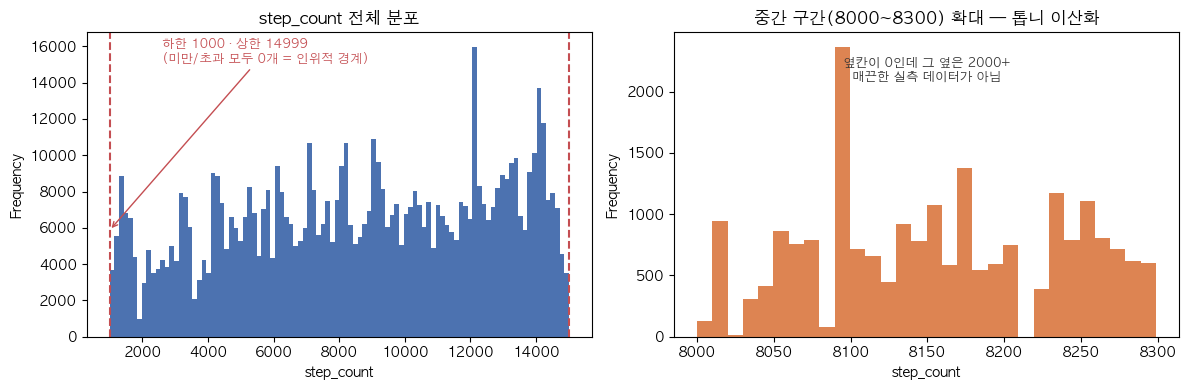

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 왼쪽: 전체 분포 + 인위적 상하한 두 개 (하한 1000, 상한 14999)
train["step_count"].plot(kind="hist", bins=100, ax=axes[0], color="#4C72B0")
axes[0].axvline(1000, color="#C44E52", ls="--", lw=1.5)
axes[0].axvline(15000, color="#C44E52", ls="--", lw=1.5)
axes[0].annotate("하한 1000 · 상한 14999\n(미만/초과 모두 0개 = 인위적 경계)",
                 xy=(1000, axes[0].get_ylim()[1] * 0.35), xytext=(2600, axes[0].get_ylim()[1] * 0.9),
                 color="#C44E52", fontsize=9, arrowprops=dict(arrowstyle="->", color="#C44E52"))
axes[0].set_title("step_count 전체 분포")
axes[0].set_xlabel("step_count")

# 오른쪽: 중간 구간 확대 → 옆칸이 0인데 옆은 급증 = 이산화(톱니)
mid = train.loc[(train["step_count"] >= 8000) & (train["step_count"] < 8300), "step_count"]
mid.plot(kind="hist", bins=30, ax=axes[1], color="#DD8452")
axes[1].set_title("중간 구간(8000~8300) 확대 — 톱니 이산화")
axes[1].set_xlabel("step_count")
axes[1].text(0.5, 0.92, "옆칸이 0인데 그 옆은 2000+\n매끈한 실측 데이터가 아님",
             transform=axes[1].transAxes, ha="center", va="top", fontsize=9, color="#333")
plt.tight_layout()
plt.show()


왼쪽에서 분포가 1000에서 칼같이 시작하고 14999에서 끊긴다. 오른쪽 중간 구간 확대를 보면 막대가 옆칸끼리 0과 2000+를 오가며 톱니처럼 튄다. 이 이산화가 15000 한 곳의 눌림보다 훨씬 뚜렷한 합성 흔적이다. 다만 이것만으로 합성을 단정하진 않는다(위 극단값 판정 참고).

### EDA 정리

- 690,088행, 15컬럼. **합성 데이터로 추정.** 근거는 카테고리 3등분(Cohen's w≈0.01), gender '기타' 31%(인구학적 불가능), 인위적 범위 제한, 그리고 결정적으로 원본 실데이터로 생성된 Kaggle Playground라는 출처다. (개별 분포 모양 하나로 단정하지 않는다.)
- 정답 분포 at-risk 85.9 / unhealthy 8.4 / fit 5.8%로 심한 불균형. 무조건 at-risk로 찍는 기준선의 정확도가 85.9%.
- 결측치는 id 빼고 전 컬럼에 1~12%. 다 지우면 절반만 남으니 지우지 않고 채운다.
- heart_rate(하한 50), step_count(하한 1000·상한 14999) 모두 인위적인 범위 제한. step_count는 이산화(톱니)까지.
- 다음 결정: 결측치를 무엇으로 채울지. 컬럼 성격을 보고 판단한다.

## 3. 전처리

채우기 방법을 정하기 전에 두 가지를 실측한다: (1) 숫자형을 평균으로 채울지 중앙값으로 채울지(→ 왜도), (2) 결측 자체가 정보를 담고 있는지(→ 결측이 타깃과 연관됐나). 

In [10]:
# 대체 방법 근거를 실측 — (1) 왜도(평균 vs 중앙값), (2) 결측의 정보성(타깃과 연관?)
from scipy.stats import chi2_contingency
import numpy as np

num_skew = train[numeric_cols].skew().round(2)

y = train["health_condition"]
rows = []
for col in numeric_cols + categorical_cols:
    miss = train[col].isna()
    ct = pd.crosstab(miss, y)
    chi2, p, _, _ = chi2_contingency(ct)
    v = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))   # Cramér's V
    rows.append({"컬럼": col, "결측률%": round(miss.mean() * 100, 1), "p값": p, "Cramér_V": round(v, 4)})
miss_table = pd.DataFrame(rows).sort_values("Cramér_V", ascending=False).reset_index(drop=True)

print("숫자형 왜도 (0에 가까울수록 대칭 → 평균≈중앙값):")
print(num_skew.to_string())
print("\n결측 ↔ 타깃 연관 (Cramér's V, 0에 가까울수록 무관):")
print(miss_table.to_string(index=False))

숫자형 왜도 (0에 가까울수록 대칭 → 평균≈중앙값):
sleep_duration        -0.01
heart_rate             0.00
bmi                    0.02
calorie_expenditure   -0.18
step_count            -0.18
exercise_duration     -0.37
water_intake           0.11

결측 ↔ 타깃 연관 (Cramér's V, 0에 가까울수록 무관):
                     컬럼  결측률%            p값  Cramér_V
                    bmi   2.0 2.941930e-144    0.0309
             heart_rate   1.1  3.860585e-03    0.0040
           water_intake   6.3  3.882816e-02    0.0031
              diet_type   1.0  3.669549e-02    0.0031
      exercise_duration   1.0  1.722688e-01    0.0023
                 gender   3.1  2.178608e-01    0.0021
          sleep_quality   8.5  3.719793e-01    0.0017
             step_count   2.0  4.536117e-01    0.0015
        smoking_alcohol   4.1  4.956056e-01    0.0014
         sleep_duration  11.0  8.511234e-01    0.0007
physical_activity_level   5.3  9.003167e-01    0.0006
    calorie_expenditure   7.7  9.072538e-01    0.0005
           stress_level  12.0  9

두 실측 다 그냥 단순하게 채워도 된다는 쪽으로 수렴한다.

- **왜도:** 7개 숫자형이 −0.37~+0.11로 거의 대칭이다. 그래서 평균≈중앙값(제일 벌어진 step_count도 8616 vs 8856). 어느 걸로 채워도 분포를 크게 안 흔드니 **평균**으로 정한다. (정규성 *검정*은 69만 행에선 뭐든 기각—'정규분포가 아니다'라고 판정—하는 함정이라 안 쓰고, 왜도라는 서술 통계로 본다.)
- **결측의 정보성:** 결측 여부와 타깃의 연관(Cramér's V)이 전부 0에 가깝다. 결측이 타깃과 무관하다는 뜻이다 — 결측이 *다른 피처*에 의존하는지는 안 쟀으니 완전 무작위(MCAR)라고까지는 말 못 한다. 값이 비었다는 사실 자체엔 예측 정보가 없어 결측 표시(indicator) 컬럼을 따로 만들 필요가 없다.
- **또 그 함정:** bmi만 p=2.9e-144로 어마어마하게 유의미해 보이지만 Cramér's V는 0.031(무시할 수준)이다. 3등분 때와 똑같은 함정으로, 69만 행에선 p가 0이어도 효과크기를 봐야 한다.

결론: 숫자형은 평균, 범주형은 "missing" 새 카테고리(무작위 결측이라 어느 쪽이든 무해하니 모델이 알아서 처리하게 둔다).

In [11]:
# 범주형 결측치 -> "missing"이라는 새 카테고리로 채우기
for col in categorical_cols:
    train[col] = train[col].fillna("missing")

# 숫자형 결측치 -> 평균으로 채우기
for col in numeric_cols:
    train[col] = train[col].fillna(train[col].mean())

# 다 채워졌는지 확인
train.isnull().sum()

id                         0
health_condition           0
sleep_duration             0
heart_rate                 0
bmi                        0
calorie_expenditure        0
step_count                 0
exercise_duration          0
water_intake               0
diet_type                  0
stress_level               0
sleep_quality              0
physical_activity_level    0
smoking_alcohol            0
gender                     0
dtype: int64

### 인코딩 — 글자를 숫자로

모델은 글자(veg, male 같은 값)를 못 읽는다. 처음이니까 일단 단순하게 진행. stress_level처럼 순서가 있는 컬럼도 구분하지 않고 범주형 전부를 원핫 인코딩(각 값마다 O/X 컬럼 생성)으로 처리했다. 순서를 살리는 인코딩은 개선 여지로 남겨뒀다.

In [12]:
# 범주형 컬럼 원핫 인코딩 (id, 정답 컬럼은 빼고)
X = pd.get_dummies(train.drop(columns=["id", "health_condition"]))
y = train["health_condition"]

print(X.shape)
X.head()

(690088, 31)


,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type_balanced,diet_type_missing,diet_type_non-veg,...,physical_activity_level_moderate,physical_activity_level_sedentary,smoking_alcohol_missing,smoking_alcohol_no,smoking_alcohol_occasional,smoking_alcohol_yes,gender_female,gender_male,gender_missing,gender_other
0,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,False,False,False,...,False,True,False,False,False,True,True,False,False,False
1,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,False,False,True,...,True,False,False,False,False,True,False,False,False,True
2,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,False,False,False,...,False,False,False,False,False,True,False,True,False,False
3,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,False,False,False,...,False,False,False,False,True,False,True,False,False,False
4,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,False,False,False,...,False,True,True,False,False,False,False,True,False,False


## 4. 첫 모델 — 검증 정확도 96.6%

데이터가 69만 행이라 5번 교차검증을 쓰면 학습을 5번 반복해서 너무 오래 걸린다. 첫 확인은 train/validation을 한 번만 나눠 빠르게 본다. `stratify=y`를 쓰는 이유: 정답이 86 / 8 / 6%로 불균형이라 무작위로 나누면 validation 쪽에 소수 클래스가 너무 적게(또는 많이) 몰릴 수 있다. stratify는 나눌 때도 원래 비율을 유지해준다.

모델은 **랜덤포레스트**를 쓴다 — 결정 나무(조건을 연달아 물어 데이터를 갈라가는 모델) 여러 그루를 각자 독립으로 키운 뒤 다수결로 답을 정하는 방식이다(`n_estimators=100`이 나무 100그루, `max_depth`가 한 그루에 질문을 몇 단까지 던지느냐다). 첫 기준선으로 흔히 쓴다.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

pred = model.predict(X_val)
acc = accuracy_score(y_val, pred)
print("검증 정확도:", round(acc, 4))
print("베이스라인(무조건 at-risk):", round((y_val == "at-risk").mean(), 4))

검증 정확도: 0.9661
베이스라인(무조건 at-risk): 0.8587


### 클래스별로 뜯어보기 — 혼동행렬

검증 정확도 96.61%가 세 클래스를 골고루 맞힌 건지, 다수인 at-risk만 잘 맞힌 건지 확인한다. 행이 실제 정답, 열이 모델 예측이다.

In [14]:
pd.crosstab(y_val, pred, rownames=["실제"], colnames=["예측"])

예측,at-risk,fit,unhealthy
실제,,,
at-risk,117760,423,329
fit,1396,6534,31
unhealthy,2489,15,9041


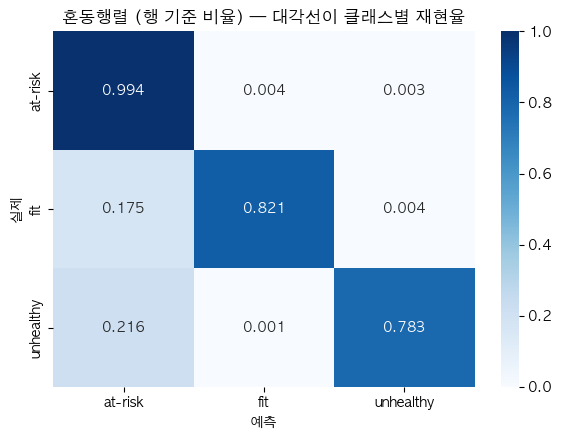

In [15]:
import seaborn as sns

# 행(실제) 기준 비율 = 그 클래스를 놓치지 않고 잡아낸 비율(재현율)
cm = pd.crosstab(y_val, pred, normalize="index")
plt.figure(figsize=(6, 4.5))
sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1)
plt.title("혼동행렬 (행 기준 비율) — 대각선이 클래스별 재현율")
plt.ylabel("실제")
plt.xlabel("예측")
plt.tight_layout()
plt.show()

at-risk는 99.4%를 잡아내지만 fit은 82%, unhealthy는 78%에 그친다. 전체 정확도 96.6%는 86%를 차지하는 at-risk를 거의 다 맞힌 덕이 크고 소수 클래스는 그만큼 못 잡는다. 이 표가 뒤에서 다시 중요해진다.

### 어떤 단서가 중요했나 — feature importance

랜덤포레스트는 학습하면서 각 단서로 나눴을 때 얼마나 잘 갈렸는지를 기록한다. `feature_importances_`로 그 값을 꺼내 이 데이터에서 실제로 뭐가 세 클래스를 가르는지 확인한다.

In [16]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
importances.head(15)

sleep_duration                       0.345610
stress_level_high                    0.115895
stress_level_low                     0.087121
stress_level_medium                  0.070466
physical_activity_level_active       0.058193
bmi                                  0.052736
step_count                           0.038189
exercise_duration                    0.037927
calorie_expenditure                  0.029593
heart_rate                           0.027744
water_intake                         0.026739
physical_activity_level_moderate     0.023642
stress_level_missing                 0.018102
physical_activity_level_sedentary    0.015083
sleep_quality_poor                   0.008441
dtype: float64

sleep_duration 혼자 34.6%, stress_level(카테고리 3개 합) 27.4%로 이 둘이 전체의 60% 이상이다. diet_type·gender·smoking_alcohol은 top 15에 없다. 수면시간과 스트레스가 지배적인 두 축이라는 걸 확인했다.

In [17]:
# 모델-무관(model-free) 중요도 교차검증 — RF 불순도 중요도가 편향됐는지 확인
# 주의: 위 train은 §3에서 fillna로 덮어썼다. 대체값(평균·"missing")이 섞이면 신호가 0쪽으로 눌리므로
#       여기선 원본을 새로 읽어 결측을 '없는 값'으로 두고 잰다.
from scipy.stats import kruskal, chi2_contingency
train_mf = pd.read_csv('train.csv')

y_col = train_mf["health_condition"]; classes = y_col.unique()
num_imp = {}
for c in numeric_cols:
    groups = [train_mf.loc[y_col == cl, c].dropna() for cl in classes]
    H, _ = kruskal(*groups)
    n, k = sum(len(g) for g in groups), len(groups)
    num_imp[c] = (H - k + 1) / (n - k)          # Kruskal-Wallis ε²
cat_imp = {}
for c in categorical_cols:
    ct = pd.crosstab(train_mf[c], y_col); chi2, _, _, _ = chi2_contingency(ct)   # 결측 행은 crosstab이 자동 제외
    cat_imp[c] = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))   # Cramér's V

print("숫자형 구분력 (Kruskal-Wallis ε²):")
print(pd.Series(num_imp).sort_values(ascending=False).round(4).to_string())
print("\n범주형 구분력 (Cramér's V):")
print(pd.Series(cat_imp).sort_values(ascending=False).round(4).to_string())

숫자형 구분력 (Kruskal-Wallis ε²):
sleep_duration         0.1946
exercise_duration      0.0384
step_count             0.0383
bmi                    0.0197
calorie_expenditure    0.0087
heart_rate             0.0001
water_intake           0.0001

범주형 구분력 (Cramér's V):
stress_level               0.4125
physical_activity_level    0.2409
sleep_quality              0.1202
smoking_alcohol            0.0764
diet_type                  0.0154
gender                     0.0131


### 모델-무관 교차검증 — RF 중요도는 대체로 맞았지만 두 곳이 틀렸다

RF는 각 피처로 나눴을 때 불순도(한 갈래에 여러 클래스가 섞인 정도)가 얼마나 줄었는지로 중요도를 매기는데, 이 방식엔 편향이 있다(연속형 쪽으로 부풀고, 원핫으로 쪼개진 범주형은 눌린다). 그래서 모델을 안 거치고 데이터 자체로 다시 측정한다(§3에서 채운 대체값이 섞이면 신호가 0쪽으로 눌리므로 원본을 새로 읽어서). 숫자형은 **Kruskal-Wallis ε²**, 범주형은 **Cramér's V**로, 둘 다 3클래스를 얼마나 가르는지를 본다. 둘 다 0이면 클래스와 무관, 1에 가까울수록 강하게 가른다(대략 0.01이면 무시, 0.1 약함, 0.3 뚜렷함 — 이름은 몰라도 되고 값만 눈금으로 읽으면 된다).

**헤드라인은 확증됐다.** sleep_duration(ε²=0.19, 숫자 중 압도적)과 stress_level(V=0.41, 범주 중 압도적)이 두 지배 축이다. RF가 찍은 1·2등이 model-free로도 1·2등이라, 도구 편향이 아니라 진짜다.

**그런데 RF가 틀린 두 곳을 model-free가 잡았다.**
- **heart_rate·water_intake는 세 클래스를 단변량으로는 못 가른다(ε²≈0.0001).** 세 클래스에서 분포가 거의 똑같다(단변량 무관이지, 모델 안에서까지 무용이란 뜻은 아니다 — 상호작용은 남는다). 그런데 RF 불순도는 이 둘에 각 0.027을 줬다. 연속형이라 트리가 아무 데서나 쪼갤 수 있어 가짜 중요도가 붙은 것이다. 우리가 우려한 편향이 실제로 있었다.
- **physical_activity_level은 강한 구분자(V=0.24)인데 RF에선 저평가됐다.** 원핫으로 더미 3개로 쪼개져 중요도가 흩어졌기 때문이다. model-free는 컬럼을 통째로 봐서 이걸 제대로 잡는다.

교훈: 중요도는 한 소스로 단정하지 말고, 성격이 다른 방법으로 교차검증한다.

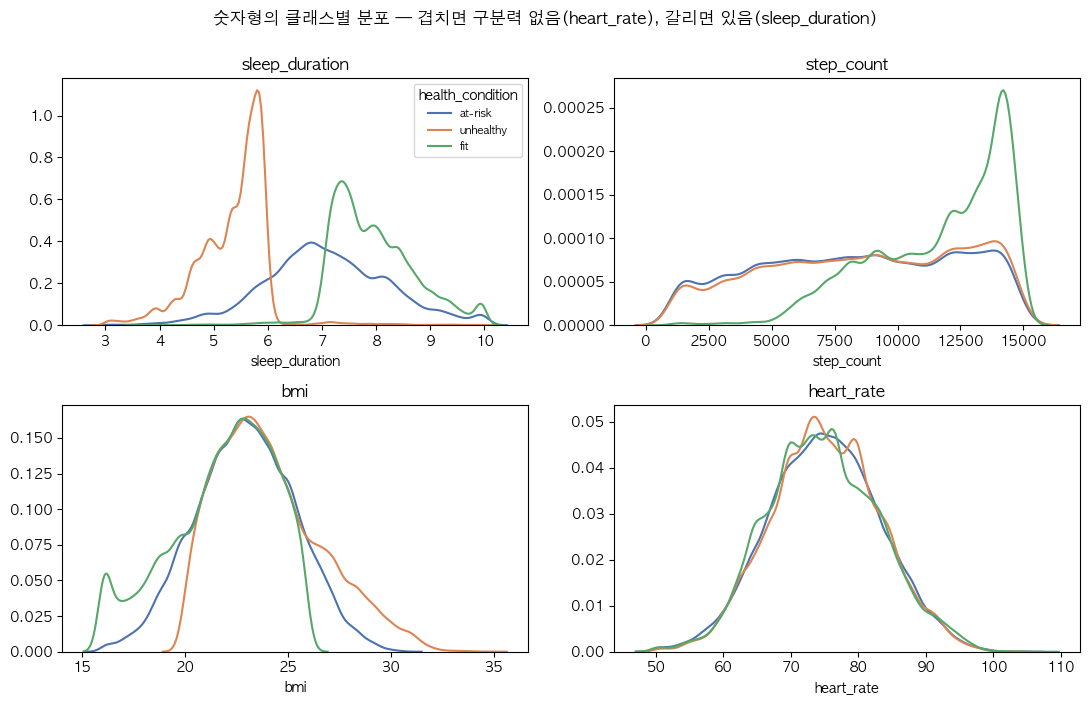

In [18]:
# 숫자형이 실제로 클래스를 가르나 — 밀도(KDE)로 눈으로 (ε² 강한 것부터 0까지)
import seaborn as sns
CLASS_COLORS = {"at-risk": "#4C72B0", "unhealthy": "#DD8452", "fit": "#55A868"}  # 이후 그림에서 재사용

feats = ["sleep_duration", "step_count", "bmi", "heart_rate"]   # ε² 0.19 → 0.0001
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, f in zip(axes.ravel(), feats):
    for cl in ["at-risk", "unhealthy", "fit"]:
        d = train_mf.loc[train_mf["health_condition"] == cl, f].dropna()   # 원본 — 대체값 6.99 스파이크 방지
        if len(d) > 40000:
            d = d.sample(40000, random_state=42)   # KDE 속도용 표본 (모양 동일)
        sns.kdeplot(d, ax=ax, label=cl, color=CLASS_COLORS[cl], common_norm=False)
    ax.set_title(f); ax.set_ylabel("")
axes[0, 0].legend(title="health_condition", fontsize=8)
fig.suptitle("숫자형의 클래스별 분포 — 겹치면 구분력 없음(heart_rate), 갈리면 있음(sleep_duration)", y=1.0)
plt.tight_layout(); plt.show()

sleep_duration은 세 클래스 밀도가 확연히 어긋나고(왼쪽 위) heart_rate는 세 곡선이 거의 포개진다(오른쪽 아래). ε² 수치(0.19 vs 0.0001)가 그림으로 그대로 보인다. heart_rate에 붙은 RF 중요도가 왜 가짜였는지 눈으로 확인된다.

## 5. 첫 제출 — 검증 96.6% vs 실제 86.2%

검증이 끝났으니 최종 모델은 데이터 전부로 다시 학습한다(retrain-on-all). test.csv도 train과 똑같이 전처리하되 컬럼 구성을 train과 정확히 맞춘다. `reindex`로 컬럼 순서를 맞추고 test에 없는 카테고리 값은 0으로 채운다.

In [19]:
# test.csv도 train과 똑같이 전처리
test = pd.read_csv("test.csv")

for col in categorical_cols:
    test[col] = test[col].fillna("missing")
for col in numeric_cols:
    test[col] = test[col].fillna(train[col].mean())  # train 기준값으로 채움

X_test = pd.get_dummies(test.drop(columns=["id"]))
X_test = X_test.reindex(columns=X.columns, fill_value=0)  # train 컬럼 구성에 맞춤

# 최종 모델: 데이터 전부로 재학습
final_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
final_model.fit(X, y)

test_pred = final_model.predict(X_test)

submission = pd.DataFrame({"id": test["id"], "health_condition": test_pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,at-risk
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


### 실제 점수 0.86217 — 10%p가 사라졌다

캐글 실제 점수는 0.86217. 검증 정확도 96.61%에서 10%p 넘게 떨어졌고 무조건 at-risk로 찍는 기준선(85.87%)과 거의 차이가 없다. 노이즈로 넘길 수준이 아니라서 원인을 추적했다.

**가설 1 — train.csv에 중복 행이 많아 검증이 오염됐다.** 확인하니 중복 행 0개. 기각.

**가설 2 — 과적합.** 훈련 정확도를 재보니 100.0%다. 자기가 배운 데이터는 하나도 안 틀린다는 건 명백한 과적합 신호다(연습문제만 달달 외워 실전에서 헛발질하는 그 현상). 그런데 과적합이 10%p 격차를 다 설명하는지는 별개 문제라서 max_depth를 바꿔가며 실험했다.

In [20]:
# max_depth별 훈련/검증 정확도 비교 (과적합 확인)
for depth in [4, 6, 8, 10, None]:
    m = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42, n_jobs=-1)
    m.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, m.predict(X_train))
    val_acc = accuracy_score(y_val, m.predict(X_val))
    print(f"max_depth={depth}: 훈련={train_acc:.4f}, 검증={val_acc:.4f}, 차이={train_acc - val_acc:.4f}")

max_depth=4: 훈련=0.8841, 검증=0.8840, 차이=0.0001


max_depth=6: 훈련=0.9451, 검증=0.9460, 차이=-0.0009


max_depth=8: 훈련=0.9634, 검증=0.9637, 차이=-0.0002


max_depth=10: 훈련=0.9649, 검증=0.9648, 차이=0.0000


max_depth=None: 훈련=1.0000, 검증=0.9661, 차이=0.0339


depth=10은 훈련≈검증(96.49 vs 96.48%)으로 과적합이 거의 없는데도 검증 정확도가 제한없음 모델(96.61%)과 0.13%p밖에 차이가 안 난다. 과적합으로 얻은 이득이 검증 기준 0.13%p뿐이라면 실제 점수 10%p 추락을 과적합만으로 설명하기 어렵다.

짐작으로 결론 내리지 않고 depth=10 모델을 실제로 제출해봤다. 결과는 0.83799. 과적합을 거의 없앤 모델이 과적합 있는 모델(0.86217)보다 오히려 더 나쁘다. 과적합이 주 원인이라는 가설로는 설명이 안 되는 결과다.

### 남은 가설 둘 — 누수는 기각, 지표가 정답이었다

**가설 3 — 파이프라인을 안 써서 생긴 데이터 누수.** 코드를 다시 보니 숫자형 결측치를 평균으로 채우는 시점이 train_test_split보다 먼저다. validation으로 빠질 20%도 평균 계산에 섞였으니 엄밀히는 누수가 실제로 있다. 그래도 기각했다. 이유는 두 가지다. 결측이 1~12%뿐이라 평균값 자체가 val 포함 여부로 거의 안 바뀌어서 10%p대 격차를 만들 수 없고, 이 누수는 트리 깊이와 무관하게 항상 같은 방식으로 작동하는데 우리가 본 현상은 깊이를 줄이면 격차가 커지는 것이라 설명이 안 된다.

**가설 4 — 검증에 쓴 지표가 채점 지표와 다르다.** 대회 페이지 Evaluation 탭을 열어 확인했다. 이 대회는 accuracy가 아니라 balanced accuracy로 채점된다. 클래스별 재현율(그 클래스를 놓치지 않고 잡아낸 비율)을 구해 데이터 비율을 무시하고 세 클래스를 똑같은 비중으로 평균 낸 값이다. 지금까지 검증에 쓴 건 전부 accuracy였다. at-risk가 86%인 데이터에서 accuracy는 다수 클래스만 잘 맞혀도 쉽게 올라간다.

이 가설은 depth=10 결과와 방향이 맞는다. 트리가 얕아지면 예측이 다수 클래스 쪽으로 더 쏠려서 accuracy는 유지되지만 소수 클래스 재현율이 떨어져 balanced accuracy는 나빠질 수 있다. 실제 관찰(제한없음 0.862 > depth=10 0.838)과 일치하는 방향이다.

대회 채점 방식은 첫날 Evaluation 탭에서 확인하는 게 정석인데 늦게 확인해서 가설 세 개를 거친 뒤에야 도달했다.

### 같은 지표로 다시 — 파이프라인 재구축

EDA와 결측치 채우기 방법은 그대로 두고 실행 코드만 파이프라인 구조로 새로 짠다. 가설 3에서 확인한 누수도 이 참에 구조적으로 없앤다. 채점은 balanced_accuracy_score로 한다.

주의: train 변수는 이미 위에서 fillna로 덮어써졌으니 train.csv를 원본 그대로 새로 불러오는 것부터 시작한다.

In [21]:
# train.csv를 원본 그대로 새로 불러옴 (위 train 변수는 이미 fillna로 덮어써졌으니까)
train_raw = pd.read_csv("train.csv")
print("결측치 다시 있는지 확인:")
print(train_raw.isnull().sum())

결측치 다시 있는지 확인:
id                             0
health_condition               0
sleep_duration             75999
heart_rate                  7833
bmi                        13898
calorie_expenditure        52853
step_count                 13916
exercise_duration           6901
water_intake               43477
diet_type                   6901
stress_level               82811
sleep_quality              58331
physical_activity_level    36621
smoking_alcohol            28582
gender                     21373
dtype: int64


In [22]:
# 전처리 조립법(preprocessor) 만들기 - 아직 데이터에 적용은 안 함, 설계도만
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# 범주형 컬럼: 빈칸 -> "missing" -> 원핫인코딩
categorical_pipeline = Pipeline([
    ("결측치_채우기", SimpleImputer(strategy="constant", fill_value="missing")),
    ("원핫인코딩", OneHotEncoder(handle_unknown="ignore")),
])

# 숫자형 컬럼: 빈칸 -> 평균
numeric_pipeline = Pipeline([
    ("결측치_채우기", SimpleImputer(strategy="mean")),
])

# 컬럼 묶음마다 다른 처리 적용
preprocessor = ColumnTransformer([
    ("범주형", categorical_pipeline, categorical_cols),
    ("숫자형", numeric_pipeline, numeric_cols),
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('범주형', ...), ('숫자형', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [23]:
# 전처리 + 모델을 하나의 파이프라인으로 묶기
full_pipeline = Pipeline([
    ("전처리", preprocessor),
    ("모델", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

X = train_raw.drop(columns=["id", "health_condition"])
y = train_raw["health_condition"]

# split을 먼저 함 - 이 시점엔 아직 아무 통계도 계산 안 됨
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# fit은 X_train에만 함 - 파이프라인 안 SimpleImputer 평균도 train에서만 배움
full_pipeline.fit(X_train, y_train)
pred = full_pipeline.predict(X_val)

from sklearn.metrics import balanced_accuracy_score

acc_rf = accuracy_score(y_val, pred)
bal_rf = balanced_accuracy_score(y_val, pred)
print("정확도(accuracy):", round(acc_rf, 4))
print("균형 정확도(balanced accuracy):", round(bal_rf, 4))

정확도(accuracy): 0.9662
균형 정확도(balanced accuracy): 0.8662


### 검증 ≈ 실제 — 추적 종결

실행 전 예측: 가설 4가 맞다면 balanced accuracy가 실제 캐글 점수 0.86217에 가깝게 나올 것이다.

결과는 accuracy 0.9662, balanced accuracy 0.8662. 착시가 그대로 재현되고 balanced accuracy는 실제 점수와 0.4%p 차이로 일치한다. 격차의 진짜 원인은 과적합도 누수도 아니고 처음부터 잘못된 지표로 검증한 것이었다. 모델은 처음부터 이 실력(약 0.86)이었고 그동안 본 96%대는 다수 클래스에 눈먼 정확도가 만든 착시였다.

depth 실험도 같은 지표로, depth=10과 제한없음은 accuracy로는 거의 동일(96.48 vs 96.61%)했지만 실제 점수는 0.838 vs 0.862로 2.4%p 차이였다. accuracy로는 안 보이던 진짜 차이가 balanced accuracy에선 확인된다.

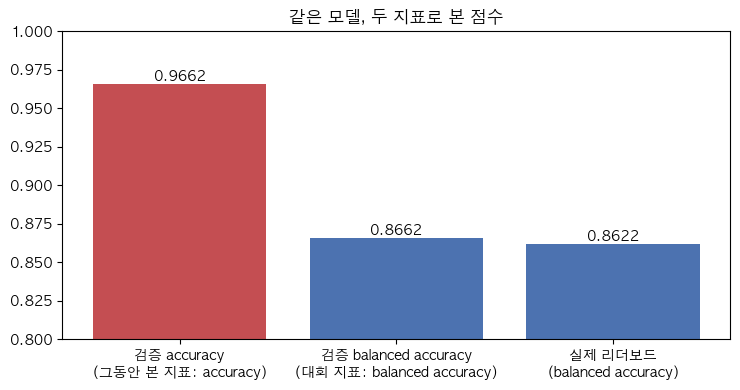

In [24]:
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar(
    ["검증 accuracy\n(그동안 본 지표: accuracy)", "검증 balanced accuracy\n(대회 지표: balanced accuracy)", "실제 리더보드\n(balanced accuracy)"],
    [acc_rf, bal_rf, 0.86217],
    color=["#C44E52", "#4C72B0", "#4C72B0"],
)
ax.bar_label(bars, fmt="%.4f")
ax.set_ylim(0.80, 1.00)
ax.set_title("같은 모델, 두 지표로 본 점수")
plt.tight_layout()
plt.show()

## 6. 개선 실험 — 오버샘플링, 그리고 부스팅

> **점수판 메모:** 이 절은 캐글에 제출하지 않고 로컬 검증(balanced accuracy)으로 후보만 추린다. 리더보드 점수판은 아직 §5의 0.862에 멈춰 있고, 여기서 고른 승자를 §7에서 처음 제출한다.

### SMOTE — 소수 클래스를 늘려서 학습

재현율이 낮은 두 클래스(fit 82%, unhealthy 78%)를 SMOTE(소수 클래스와 닮은 합성 데이터를 만들어 늘리는 오버샘플링)로 보강해본다. 원칙: SMOTE는 train에만 적용하고 val은 원본 그대로 둔다. val이 건드리지 않은 진짜 시험이어야 검증이 의미 있다.

sklearn의 Pipeline은 값만 바꾸는 변환만 연결할 수 있다. SMOTE는 행 개수 자체를 늘리는 리샘플링이라 imbalanced-learn의 전용 Pipeline을 쓴다. 이 안에서는 학습할 때만 SMOTE가 작동하고 예측할 땐 자동으로 건너뛴다.

In [25]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# preprocessor는 위에서 이미 만든 것 재사용 - 전처리와 모델 사이에 "오버샘플링" 단계만 끼워넣음
smote_pipeline = ImbPipeline([
    ("전처리", preprocessor),
    ("오버샘플링", SMOTE(random_state=42)),
    ("모델", RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
])

smote_pipeline

,steps,"[('전처리', ...), ('오버샘플링', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('범주형', ...), ('숫자형', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The 

In [26]:
smote_pipeline.fit(X_train, y_train)
pred_smote = smote_pipeline.predict(X_val)  # X_val은 원본 그대로 - predict할 땐 SMOTE 단계가 건너뛰어짐
bal_smote = balanced_accuracy_score(y_val, pred_smote)

print("SMOTE 적용 전 balanced accuracy:", round(bal_rf, 4))
print("SMOTE 적용 후 balanced accuracy:", round(bal_smote, 4))

SMOTE 적용 전 balanced accuracy: 0.8662
SMOTE 적용 후 balanced accuracy: 0.8687


0.8662 → 0.8687. 오르긴 했는데 0.25%p로 작다. 단일 holdout 검증에선 이 정도 차이가 운으로 갈릴 수 있다는 한계도 있다(8절 참고).

### 부스팅 3종 — 기본값 비교

XGBoost·LightGBM·CatBoost를 전부 기본값(튜닝 없음)으로, 지금까지 쓰던 전처리를 그대로 붙여 비교한다. 목적은 어느 라이브러리가 낫냐를 정밀하게 가리는 게 아니라 배깅(여러 나무를 각자 독립으로 키워 평균 내는 방식, 랜덤포레스트) vs 부스팅(앞 나무가 틀린 걸 다음 나무가 이어 고쳐가며 키우는 방식)의 힘 차이부터 가늠하는 것이다.

판단 기준을 미리 정했다. 기본값끼리 1%p 이상 벌어지면 그 1등만 집중 튜닝(모델의 설정값 — 나무 깊이·학습률 같은 손잡이를 바꿔가며 더 나은 조합을 찾는 것)하고 1%p 미만이면 상위 후보를 남겨두고 판단을 보류한다.

In [27]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost는 이 버전에서 문자열 정답('at-risk' 등)을 안 받고 0,1,2 숫자만 받음 -> 숫자로 변환
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)

xgb_pipeline = Pipeline([
    ("전처리", preprocessor),
    ("모델", XGBClassifier(random_state=42, n_jobs=-1)),
])
xgb_pipeline.fit(X_train, y_train_enc)
pred_xgb = xgb_pipeline.predict(X_val)
bal_xgb = balanced_accuracy_score(y_val_enc, pred_xgb)
print("XGBoost (기본값) balanced accuracy:", round(bal_xgb, 4))

XGBoost (기본값) balanced accuracy: 0.8803


In [28]:
from lightgbm import LGBMClassifier
import warnings

# 파이프라인 내부에서 numpy 배열로 변환돼 생기는 컬럼명 안내 경고 숨김 (결과에 영향 없음)
warnings.filterwarnings("ignore", message="X does not have valid feature names")

lgbm_pipeline = Pipeline([
    ("전처리", preprocessor),
    ("모델", LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)),
])
lgbm_pipeline.fit(X_train, y_train)
pred_lgbm = lgbm_pipeline.predict(X_val)
bal_lgbm = balanced_accuracy_score(y_val, pred_lgbm)
print("LightGBM (기본값) balanced accuracy:", round(bal_lgbm, 4))

LightGBM (기본값) balanced accuracy: 0.8749


In [29]:
from catboost import CatBoostClassifier

cat_pipeline = Pipeline([
    ("전처리", preprocessor),
    ("모델", CatBoostClassifier(random_state=42, verbose=0)),
])
cat_pipeline.fit(X_train, y_train)
pred_cat = cat_pipeline.predict(X_val).ravel()  # catboost는 (n,1) 모양으로 반환해서 1차원으로 펴줌
bal_cat = balanced_accuracy_score(y_val, pred_cat)
print("CatBoost (기본값) balanced accuracy:", round(bal_cat, 4))

CatBoost (기본값) balanced accuracy: 0.8786


In [30]:
print("=== 기본값 비교 (balanced accuracy, 같은 val 세트) ===")
print("랜덤포레스트 (SMOTE 없음):", round(bal_rf, 4))
print("랜덤포레스트 + SMOTE:     ", round(bal_smote, 4))
print("XGBoost (기본값):        ", round(bal_xgb, 4))
print("LightGBM (기본값):       ", round(bal_lgbm, 4))
print("CatBoost (기본값):       ", round(bal_cat, 4))

=== 기본값 비교 (balanced accuracy, 같은 val 세트) ===
랜덤포레스트 (SMOTE 없음): 0.8662
랜덤포레스트 + SMOTE:      0.8687
XGBoost (기본값):         0.8803
LightGBM (기본값):        0.8749
CatBoost (기본값):        0.8786


부스팅 셋 다 랜덤포레스트(0.8662~0.8687)를 확실히 이긴다. XGBoost 0.8803 > CatBoost 0.8786 > LightGBM 0.8749. 부스팅끼리 격차는 제일 큰 것도 0.54%p로 미리 정한 기준(1%p) 미만이라 승자를 못 정했다.

그런데 이 비교엔 모순이 있다. 각 라이브러리의 특수 능력(XGBoost의 결측치 자동 학습, CatBoost의 범주형 자동 처리)을 꺼놓고 우리가 만든 원핫·평균대체 전처리를 똑같이 통과시킨 손발 묶은 비교이다. 그 능력들이 각 라이브러리가 실전에서 강한 이유인데 꺼놓고 비교하면 실제로 뭘 써야 하나라는 질문에 답이 안 된다. 각자 네이티브 방식으로 다시 비교한다.

### 네이티브 능력을 켜고 재비교

전처리기 없이 각 라이브러리에 맞는 최소 준비만 한다.

- XGBoost·LightGBM: 범주형 컬럼을 원핫 대신 `category` dtype으로 넘긴다(자체적으로 범주 인식). 결측치는 채우지 않고 그대로 둔다(둘 다 자동 처리).
- CatBoost: 원본 그대로 두고 `cat_features` 파라미터로 범주형 컬럼만 알려준다. 단 범주형 결측치는 문자열을 요구해서 EDA 때 정한 "missing" 채우기를 재사용한다.

In [31]:
# XGBoost/LightGBM용 - 범주형 컬럼만 category dtype으로 변환 (결측치는 그대로 둠)
X_train_native = X_train.copy()
X_val_native = X_val.copy()
for col in categorical_cols:
    X_train_native[col] = X_train_native[col].astype("category")
    X_val_native[col] = X_val_native[col].astype("category")

X_train_native.dtypes

sleep_duration              float64
heart_rate                  float64
bmi                         float64
calorie_expenditure         float64
step_count                  float64
exercise_duration           float64
water_intake                float64
diet_type                  category
stress_level               category
sleep_quality              category
physical_activity_level    category
smoking_alcohol            category
gender                     category
dtype: object

In [32]:
# XGBoost 네이티브: enable_categorical=True로 category 컬럼 자체 인식 + 결측치 자동학습
xgb_native = XGBClassifier(random_state=42, n_jobs=-1, enable_categorical=True, tree_method="hist")
xgb_native.fit(X_train_native, y_train_enc)
pred_xgb_native = xgb_native.predict(X_val_native)
bal_xgb_native = balanced_accuracy_score(y_val_enc, pred_xgb_native)
print("XGBoost (네이티브) balanced accuracy:", round(bal_xgb_native, 4))

XGBoost (네이티브) balanced accuracy: 0.8819


In [33]:
# LightGBM 네이티브: category 컬럼 자동 인식 + 결측치 자동학습
lgbm_native = LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
lgbm_native.fit(X_train_native, y_train)
pred_lgbm_native = lgbm_native.predict(X_val_native)
bal_lgbm_native = balanced_accuracy_score(y_val, pred_lgbm_native)
print("LightGBM (네이티브) balanced accuracy:", round(bal_lgbm_native, 4))

LightGBM (네이티브) balanced accuracy: 0.8739


In [34]:
# CatBoost는 범주형 컬럼의 결측치(NaN)를 문자열로 요구함 (숫자 컬럼 결측치는 그대로 둬도 됨 - 자동 처리)
# EDA 때 이미 내린 결정 재사용: 범주형 결측 -> "missing" 카테고리
X_train_cat = X_train.copy()
X_val_cat = X_val.copy()
for col in categorical_cols:
    X_train_cat[col] = X_train_cat[col].fillna("missing")
    X_val_cat[col] = X_val_cat[col].fillna("missing")

cat_native = CatBoostClassifier(random_state=42, verbose=0, cat_features=categorical_cols)
cat_native.fit(X_train_cat, y_train)
pred_cat_native = cat_native.predict(X_val_cat).ravel()
bal_cat_native = balanced_accuracy_score(y_val, pred_cat_native)
print("CatBoost (네이티브) balanced accuracy:", round(bal_cat_native, 4))

CatBoost (네이티브) balanced accuracy: 0.8757


In [35]:
results = {
    "랜덤포레스트": bal_rf,
    "랜덤포레스트 + SMOTE": bal_smote,
    "XGBoost (전처리 통일)": bal_xgb,
    "LightGBM (전처리 통일)": bal_lgbm,
    "CatBoost (전처리 통일)": bal_cat,
    "XGBoost (네이티브)": bal_xgb_native,
    "LightGBM (네이티브)": bal_lgbm_native,
    "CatBoost (네이티브)": bal_cat_native,
}
print("=== 전체 비교 (balanced accuracy) ===")
for name, score in results.items():
    print(f"{name:<20} {score:.4f}")

=== 전체 비교 (balanced accuracy) ===
랜덤포레스트               0.8662
랜덤포레스트 + SMOTE       0.8687
XGBoost (전처리 통일)     0.8803
LightGBM (전처리 통일)    0.8749
CatBoost (전처리 통일)    0.8786
XGBoost (네이티브)       0.8819
LightGBM (네이티브)      0.8739
CatBoost (네이티브)      0.8757


### 판정 — 네이티브가 항상 낫진 않았다

예상과 반대로 네이티브 모드에서 XGBoost만 좋아지고(0.8803 → 0.8819) LightGBM·CatBoost는 살짝 나빠졌다(0.8749 → 0.8739, 0.8786 → 0.8757). 특수 능력을 켜는 게 항상 낫다는 가정이 이 데이터에선 안 맞는다.

짐작(미검증): 이 데이터의 범주형은 컬럼마다 값이 3~4개뿐인 저카디널리티다. 범주형 자동 처리는 범주가 수백~수천 개일 때 이득이 큰데 이렇게 적으면 원핫 인코딩도 이미 충분해서 특수 처리가 득이 안 될 수 있다. 확인하려면 고카디널리티 데이터로 대조 실험이 필요한데 지금은 하지 않는다.

확실한 결론: 부스팅(0.874~0.882) vs 랜덤포레스트(0.866~0.869)의 격차 0.5~1.6%p는 신뢰할 만하다. 부스팅끼리 격차(최대 0.8%p)는 여전히 애매해서 진짜 1등은 단정 못 한다. 현재 1위는 XGBoost(네이티브) 0.8819.

## 7. 1차 제출 — XGBoost(네이티브)

검증에서 제일 좋았던 XGBoost(네이티브, 0.8819)로 **일단 제출**한다. 여기가 끝이 아니다. §8에서 검증을 CV로 튼튼히 하고, §9에서 결정 규칙으로 0.95 근처까지 간다. 검증은 끝났으니 데이터 전부로 재학습(retrain-on-all)하고 test.csv를 예측한다.

In [36]:
# 데이터 전부로 재학습 (X, y = train_raw 전체, 검증 없이 다 씀)
X_native_full = X.copy()
for col in categorical_cols:
    X_native_full[col] = X_native_full[col].astype("category")
y_full_enc = le.transform(y)  # le는 위에서 이미 3개 클래스 다 fit된 상태

final_xgb = XGBClassifier(random_state=42, n_jobs=-1, enable_categorical=True, tree_method="hist")
final_xgb.fit(X_native_full, y_full_enc)
print("재학습 완료, 학습 데이터 크기:", X_native_full.shape)

재학습 완료, 학습 데이터 크기: (690088, 13)


In [37]:
# test.csv 새로 불러와서(결측치 안 채움, 그대로) 범주형만 category dtype으로
test_raw = pd.read_csv("test.csv")
X_test_native = test_raw.drop(columns=["id"]).copy()
for col in categorical_cols:
    X_test_native[col] = X_test_native[col].astype("category")
X_test_native = X_test_native.reindex(columns=X.columns)

test_pred_enc = final_xgb.predict(X_test_native)
test_pred = le.inverse_transform(test_pred_enc)  # 숫자 -> 'at-risk' 같은 원래 글자로

submission = pd.DataFrame({"id": test_raw["id"], "health_condition": test_pred})
submission.to_csv("submission.csv", index=False)
submission.head()

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


### 결과 — 0.87828 (현재 최고점)

캐글 실제 점수 0.87828.

- 검증 0.8819 → 실제 0.87828로 차이가 0.36%p다. accuracy로 검증하던 때 10%p 넘게 벌어졌던 것과 비교하면 검증이 실전을 잘 예측한다. 지표를 고친 효과가 실측으로 확인됐다.
- 기존 최고 0.86217(랜덤포레스트)에서 1.6%p 개선. 점수판: 0.862 → 0.878.
- 하지만 여기가 끝이 아니다. 다음 두 절에서 검증을 CV로 더 튼튼히 하고(§8), 결정 규칙 보정으로 0.95 근처까지 간다(§9).

**한 가지 미리 정리 — 다음 절부터 파이프라인을 전처리통일로 되돌린다.** 네이티브가 로컬 0.8819로 근소 1위였지만, 그 차이는 곧(§8) paired 검정으로 노이즈에 가까운 작은 차로 판명되고 최종 점수를 못 바꾼다. 무엇보다 CV·OOF·β 보정(OOF·paired는 바로 다음 §8에서 설명)을 하나의 기준으로 이어 재려면 파이프라인이 일관돼야 해서, 이후 전 과정은 재현이 깔끔한 전처리통일 XGB로 통일한다(네이티브와 최종 점수 차 없음). 그래서 §9의 최고점 β 모델도 네이티브가 아니라 이 전처리통일 XGB다.

## 8. 교차검증(CV)으로 검증을 튼튼하게 — 그리고 OOF

여기까지 검증은 전부 **단일 holdout**(데이터를 한 번만 8:2로 나눔)이었다. 문제는 그 한 번의 분할에 운이 섞인다는 것이다. 채점 조각이 우연히 쉬우면 점수가 부풀고, 어려우면 깎인다.

교차검증(CV)은 데이터를 여러 조각(폴드)으로 나눠 돌아가며 채점하고 평균을 낸다. 운이 서로 상쇄돼 진짜 실력에 가까운 값과, 폴드 간 흔들림 폭(표준편차)을 같이 얻는다. 흔들림 폭은 이 검증의 오차라, 어떤 개선이 진짜인지 노이즈인지 판정하는 기준이 된다.

`StratifiedKFold`를 쓰는 이유: 불균형 데이터(at-risk 86%)라 폴드마다 클래스 비율을 원본과 똑같이 유지해야 balanced accuracy를 제대로 측정한다. 소수 클래스가 어떤 폴드에 하나도 안 들어가면 그 클래스의 재현율을 측정할 수 없기 때문이다.

In [38]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import numpy as np

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# full_pipeline(전처리+랜덤포레스트)을 통째로 넘긴다.
# → 폴드마다 전처리(평균 채우기·원핫)를 그 폴드의 '학습 조각'에서만 새로 배움 = 데이터 누수 차단
cv_results = cross_validate(full_pipeline, X, y, cv=cv, scoring="balanced_accuracy")
scores = cv_results["test_score"]
print("폴드별 balanced accuracy:", np.round(scores, 4).tolist())
print("평균:", round(scores.mean(), 4), " 흔들림 폭(std):", round(scores.std(), 4))
print("단일 holdout(4절) 비교:", round(bal_rf, 4))

폴드별 balanced accuracy: [0.8638, 0.8665, 0.8672, 0.8626, 0.8633]
평균: 0.8647  흔들림 폭(std): 0.0018
단일 holdout(4절) 비교: 0.8662


실행 결과: 폴드별 [0.8638, 0.8665, 0.8672, 0.8626, 0.8633], **평균 0.8647, 흔들림 폭 0.0018**.

단일 holdout 0.8662는 CV 평균 0.8647보다 살짝 위인데, 그때 분할이 운이 좋았다는 뜻이다. 다만 폴드 범위(0.8626~0.8672) 안이라 크게 벗어난 건 아니고, 이 대회에선 단일 holdout도 그럭저럭 믿을 만했다(그래서 리더보드 0.86217과도 얼추 맞았다). 무엇보다 오차 ±0.0018을 실측한 게 소득이다. 이 값보다 작은 점수 차이는 앞으로 노이즈로 봐야 한다.

(참고: SMOTE도 같은 CV로 재보니 평균 0.8676으로 RF보다 +0.0029다. 흔들림 폭보다 살짝 커서 약한 진짜 신호였다. 하지만 뒤의 부스팅에 한참 밀려 최종에는 쓰지 않는다.)

### ±0.0018은 모델 비교엔 안 맞는 값이다 — paired 검정으로 결판

방금 쓴 ±0.0018은 **각 모델의 폴드 흔들림(marginal std)**이다. 그런데 두 모델을 같은 폴드에서 측정하면 폴드 난이도(그 흔들림의 주범)가 차이에서 상쇄된다. 같은 시험지로 두 학생을 비교하면 시험이 어렵든 쉽든 둘 다 똑같이 영향받아 점수 차만 깨끗이 남는 것과 같다. 그래서 모델 비교에서 봐야 할 건 marginal std가 아니라 폴드별 차이(그 점수 차)의 흔들림이고, 보통 훨씬 작다. §6에서 노이즈라 못 정한다고 미룬 부스팅 1등을, 여기서 같은 5폴드로 paired 비교해 결판낸다.

In [39]:
# 부스팅 3종을 같은 5폴드에서 paired 비교 (5폴드 × 3모델 = 몇 분 걸린다)
from scipy.stats import ttest_rel
from sklearn.preprocessing import LabelEncoder

y_cmp = LabelEncoder().fit_transform(y)
def make(m):
    if m == "XGBoost":  return XGBClassifier(random_state=42, n_jobs=-1)
    if m == "LightGBM": return LGBMClassifier(random_state=42, n_jobs=-1, verbose=-1)
    return CatBoostClassifier(random_state=42, verbose=0)

fold_bal = {m: [] for m in ["XGBoost", "LightGBM", "CatBoost"]}
for tr_idx, va_idx in cv.split(X, y_cmp):          # cv = 위에서 만든 StratifiedKFold (같은 폴드)
    for m in fold_bal:
        pipe = Pipeline([("전처리", preprocessor), ("모델", make(m))])
        pipe.fit(X.iloc[tr_idx], y_cmp[tr_idx])
        fold_bal[m].append(balanced_accuracy_score(y_cmp[va_idx], pipe.predict(X.iloc[va_idx])))

print("모델별 5폴드 평균 (marginal std = 각자의 폴드 흔들림):")
for m, s in fold_bal.items():
    print(f"  {m:<10} {np.mean(s):.4f}  (std {np.std(s):.4f})")
print("\n같은 폴드 paired 비교 (차이의 std가 훨씬 작다):")
for a, b in [("XGBoost", "CatBoost"), ("XGBoost", "LightGBM"), ("CatBoost", "LightGBM")]:
    diff = np.array(fold_bal[a]) - np.array(fold_bal[b])
    _, p = ttest_rel(fold_bal[a], fold_bal[b])
    signs = "".join("+" if d > 0 else "-" for d in diff)
    print(f"  {a} - {b}: 평균차 {diff.mean():+.4f}, 5폴드 부호 {signs}, 차이std {diff.std():.5f}, paired-t p={p:.1e}(안 씀)")

모델별 5폴드 평균 (marginal std = 각자의 폴드 흔들림):
  XGBoost    0.8796  (std 0.0020)
  LightGBM   0.8742  (std 0.0017)
  CatBoost   0.8766  (std 0.0016)

같은 폴드 paired 비교 (차이의 std가 훨씬 작다):
  XGBoost - CatBoost: 평균차 +0.0030, 5폴드 부호 +++++, 차이std 0.00058, paired-t p=4.9e-04(안 씀)
  XGBoost - LightGBM: 평균차 +0.0054, 5폴드 부호 +++++, 차이std 0.00045, paired-t p=1.9e-05(안 씀)
  CatBoost - LightGBM: 평균차 +0.0024, 5폴드 부호 +++++, 차이std 0.00042, paired-t p=3.4e-04(안 씀)


실행 결과 — **부스팅 1등은 사실 노이즈가 아니었다.**

| 비교 | 평균차 | 차이의 std |
|---|---|---|
| XGB − CatBoost | +0.0030 | 0.00058 |
| XGB − LightGBM | +0.0054 | 0.00045 |
| CatBoost − LightGBM | +0.0024 | 0.00042 |

깨끗한 근거는 두 가지다. 5폴드 전부에서 XGB가 같은 부호로 이겼고(부호 일관성), 그 평균차(~0.005)가 marginal 노이즈(±0.0018)보다 크다. (차이의 std 자체도 같은 데이터를 겹쳐 쓴 폴드에서 나온 값이라 그대로 믿긴 어렵다. 그래서 근거로는 폴드별 부호 일관성과 효과 크기만 쓴다.) 그래서 §6에서 노이즈라 1등 못 정한다고 미룬 판정이 뒤집힌다. XGB > CatBoost > LightGBM 순서는 실재한다.

(paired t-검정도 돌렸지만 p값은 안 쓴다. 5개 폴드가 학습 데이터를 겹쳐 써서 독립이 아니라, 그 p는 유효한 유의수준이 아니다. 근거는 p가 아니라 부호 일관성이다.)

알 수 있는 점은 둘이다. ① 비교엔 marginal std(±0.0018)가 아니라 같은 폴드에서 본 부호 일관성과 효과 크기를 써야 한다. 안 그러면 0.0018보다 작은 진짜 차이를 노이즈로 묻는다. ② 그렇다고 이 순서가 최종 결과를 바꾸진 않는다. β 보정을 얹으면 XGB+β는 0.9494로 실측됐고, CAT·LGB도 β 후 비슷한 값으로 수렴할 것으로 보여(둘은 실측 안 함) XGB냐 LGBM이냐(0.005 차)는 사실상 무의미하다.

### OOF(Out-Of-Fold) — 한 번 돌려 재활용하는 정직한 확률

CV로 5조각을 돌 때, 각 조각을 자기가 학습에 안 낀 모델이 예측한다. 그 예측을 모으면 전체 690k 행의 치팅 없는 확률이 된다(각 행은 자기 정답을 학습에서 본 적 없는 모델이 예측한 것으로, 데이터 누수와 정확히 같은 원리로 막는다). 이걸 한 번 만들어두면, 뒤에서 결정 규칙을 아무리 많이 시험해도 이 저장된 확률에 계산만 하면 된다. (XGB 기준 전체 690k OOF 생성이 약 19초)

In [40]:
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import balanced_accuracy_score
import numpy as np

# XGB는 정답을 숫자로 받으므로 인코딩 (le.classes_ = ['at-risk','fit','unhealthy'])
le = LabelEncoder()
y_enc = le.fit_transform(y)

# xgb_pipeline은 6절에서 만든 것(전처리+XGB) 재사용.
# OOF: 각 행이 '채점 조각'일 때의 확률만 모음 → 전체 train의 '치팅 없는' 확률
oof_proba = cross_val_predict(xgb_pipeline, X, y_enc, cv=cv, method="predict_proba")
np.save('oof_proba.npy', oof_proba); np.save('y_enc.npy', y_enc)  # 뒤 calibration 절에서 로드

print("OOF 확률 shape:", oof_proba.shape)
print("보정 전(그냥 argmax) balanced accuracy:",
      round(balanced_accuracy_score(y_enc, oof_proba.argmax(axis=1)), 4))


OOF 확률 shape: (690088, 3)
보정 전(그냥 argmax) balanced accuracy: 0.8796


보정 전(그냥 제일 높은 확률 선택) balanced accuracy = **0.8796**. 상위권 공개 노트북 조사에서 본 XGB의 raw argmax(0.878)와 거의 같은 출발선이다(0.0016 차). 상위권과의 격차는 모델이 아니라 다음의 결정 규칙에서 난다.

## 9. 결정 규칙 보정 — 모델을 안 바꾸고 +0.07

모델은 세 클래스에 확률을 매기고 제일 높은 걸 답으로 고른다(argmax). 그런데 at-risk가 86%라, 모델이 애매하면 자꾸 at-risk로 찍는다. 그게 accuracy엔 유리하지만 balanced accuracy(세 클래스를 똑같은 비중으로 평균)엔 손해다. 소수 클래스(fit·unhealthy)를 놓치기 때문이다.

**보정: 각 클래스 확률을 그 클래스의 원래 비율로 나눈다.** 흔한 클래스(at-risk)는 큰 수로 나뉘어 페널티, 드문 클래스는 작은 수로 나뉘어 보너스를 받는다. 나누는 세기를 β로 조절한다(β=0이면 보정 없음, 클수록 소수 쪽으로 더 쏠림). 모델은 그대로 두고 답 고르는 규칙만 바꾸는 것이라 재학습이 필요 없다.

왜 다수 클래스를 일부러 희생하나. balanced accuracy가 평균이라, 이미 99% 잡는 at-risk에서 조금 깎여도 78~82%인 소수 클래스를 크게 올리면 평균이 오른다. 세 과목 평균에서 이미 99점인 국어를 지키는 것보다 낮은 영어·수학을 끌어올리는 게 이득인 것과 같다. 이건 채점 지표가 balanced accuracy라서 성립하는 전략이다(accuracy 대회였으면 오히려 손해). 참고로 무조건 한 클래스로만 찍으면 재현율 1·0·0의 평균 0.333이 나온다 — 이 지표의 찍기 기준선(chance level)이다(최솟값은 0, 전부 틀릴 때).

파이프라인을 한 줄로 보면 [원본 → 전처리 → XGBoost → 확률(predict_proba)]까지가 **모델**이고, 그 뒤 [÷ prior^β → argmax] 두 단계가 **결정 규칙**이다. +0.07은 앞쪽 모델을 하나도 안 건드리고 뒤쪽 결정 규칙만 바꿔 얻었다. 모델을 재학습한 게 아니라 이미 뽑은 확률에 나눗셈 한 번을 더한 것이다. 요점은 그 경계 하나 — 모델은 그대로 두고 답 고르는 규칙만 교체한 것이다.

### 왜 이게 '베이지안'인가 — 사전확률(prior) 벗겨내기

> 앞 절의 "흔한 클래스엔 페널티, 드문 클래스엔 보너스"만으로 β 작동은 이미 충분하다. 아래는 그게 왜 '베이즈'인지 궁금한 사람을 위한 보론이다.

**먼저 숫자로 한 번.** 어떤 학생에게 모델이 (설명 편의상 두 후보만 보면) at-risk 55%, fit 45%로 확률을 줬다고 하자. 그냥 제일 큰 걸 고르면(argmax) at-risk다. 그런데 at-risk는 원래 86%나 흔한 클래스라, 이 55% 안엔 "원래 흔하니까 일단 높게 깔린" 프리미엄이 껴 있다. 그 프리미엄을 빼려고 각 확률을 그 클래스의 원래 비율로 나눈다. at-risk 0.55 / 0.86 = 0.64, fit 0.45 / 0.06 = 7.5. **fit이 이긴다.** "원래 흔한 정도"를 벗겨내니 답이 뒤집혔다. 이게 prior로 나눈다는 것의 실제 계산이다.

이걸 식으로 쓰면 **베이즈 정리**다. 말로 풀면, 어떤 클래스일 확률 = (그 클래스라면 이 데이터가 나올 법한 정도) × (그 클래스가 원래 흔한 정도).

$$P(\text{클래스} \mid \text{데이터}) \;\propto\; P(\text{데이터} \mid \text{클래스}) \;\times\; \underbrace{P(\text{클래스})}_{\text{사전확률 prior}}$$

모델이 내놓는 확률 $P(\text{클래스}\mid\text{데이터})$ 안에는 이미 그 "원래 흔한 정도"(prior)가 곱해져 있다. prior로 나누는 것은 그걸 도로 벗겨내, 세 클래스가 똑같이 흔했다면 나왔을 확률로 바꾸는 셈이다. β는 얼마나 벗겨낼지의 세기다(β=1이면 완전히, β=0이면 그대로 둠).

즉 이 결정규칙 보정은 argmax의 기준을 데이터에 있던 불균형 사전확률에서 균등 사전확률 가정으로 옮기는 **베이지안 조정**이고, ISLP(통계학습 입문서) 4장의 **베이즈 분류기(사전확률이 결정 경계를 정한다)**와 같은 뿌리다. 채점 지표(balanced accuracy)가 세 클래스를 똑같이 취급하니, 결정도 균등 prior로 맞추는 게 이론적으로 맞다.

prior 나눗셈은 불균형 데이터 + 매크로 평균 지표에서 널리 쓰는 표준 수법이다(threshold-moving 또는 prior-shift).

In [41]:
prior = np.bincount(y_enc) / len(y_enc)   # 클래스별 원래 비율 [at-risk, fit, unhealthy]

print(f"{'베타':>5} | balanced accuracy")
print("-" * 28)
for beta in [0.0, 0.3, 0.5, 0.7, 0.9, 1.0, 1.1, 1.2, 1.5]:
    pred = (oof_proba / (prior ** beta)).argmax(axis=1)   # 확률을 원래비율^β로 나눔
    print(f"{beta:>5.1f} | {balanced_accuracy_score(y_enc, pred):.4f}")

   베타 | balanced accuracy
----------------------------
  0.0 | 0.8796
  0.3 | 0.9213
  0.5 | 0.9389
  0.7 | 0.9463


  0.9 | 0.9490


  1.0 | 0.9494
  1.1 | 0.9494
  1.2 | 0.9491
  1.5 | 0.9457


실행 결과:

| β | balanced accuracy |
|---|---|
| 0.0 | 0.8796  (보정 전) |
| 0.5 | 0.9389 |
| 0.9 | 0.9490 |
| 1.0 | 0.9494 |
| **1.1** | **0.9494  (최고)** |
| 1.2 | 0.9491 |
| 1.5 | 0.9457 |

**0.8796 → 0.9494 (+0.0698).** 모델은 한 글자도 안 바꾸고, 이미 뽑아둔 확률에 나눗셈 한 번 한 결과다. β=1.1을 넘으면(1.2, 1.5) 점수가 다시 내려간다. 너무 세게 나누면 at-risk가 과하게 깎여 그 재현율이 폭락하고 평균도 떨어지기 때문이다. 딱 좋은 지점이 중간(β≈1.0~1.1)에 있다.

**정직하게 두 가지.** ① 이 β는 OOF에서 골랐으니 데이터 누수는 없다(각 확률이 치팅 없이 만들어짐). 하지만 9개 값 중 최고를 골랐다는 미세한 낙관 편향은 남는다(§10의 Optuna "25번 중 최고" 편향과 같은 종류). ② 그런데 β=1.1은 이론적 근거가 있는 β=1.0(균등 prior, 위 §9에서 설명)과 OOF가 4자리까지 동일하다(둘 다 0.9494). 그래서 편향의 실질 크기가 0에 가깝고, 더 방어적으로는 β=1.0을 쓰는 게 맞다(같은 점수).

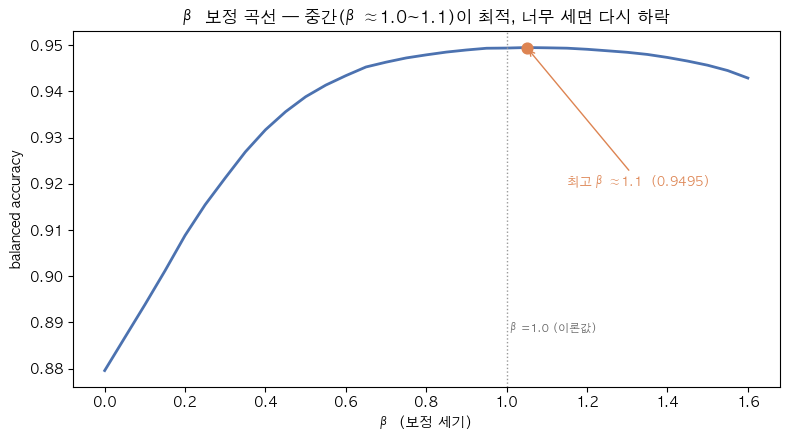

In [42]:
# β 곡선 — 왜 β≈1.0~1.1이 최적이고 더 세게 가면 다시 떨어지나
betas = np.linspace(0, 1.6, 33)
curve = [balanced_accuracy_score(y_enc, (oof_proba / prior ** b).argmax(1)) for b in betas]
best = betas[int(np.argmax(curve))]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(betas, curve, color="#4C72B0", lw=2)
ax.scatter([best], [max(curve)], color="#DD8452", zorder=5, s=60)
ax.annotate(f"최고 β≈{best:.1f}  ({max(curve):.4f})", xy=(best, max(curve)),
            xytext=(best + 0.1, max(curve) - 0.03), fontsize=9, color="#DD8452",
            arrowprops=dict(arrowstyle="->", color="#DD8452"))
ax.axvline(1.0, color="#999", ls=":", lw=1)
ax.text(1.0, min(curve) + 0.008, " β=1.0 (이론값)", fontsize=8, color="#666", va="bottom")
ax.set_xlabel("β (보정 세기)"); ax.set_ylabel("balanced accuracy")
ax.set_title("β 보정 곡선 — 중간(β≈1.0~1.1)이 최적, 너무 세면 다시 하락")
plt.tight_layout(); plt.show()

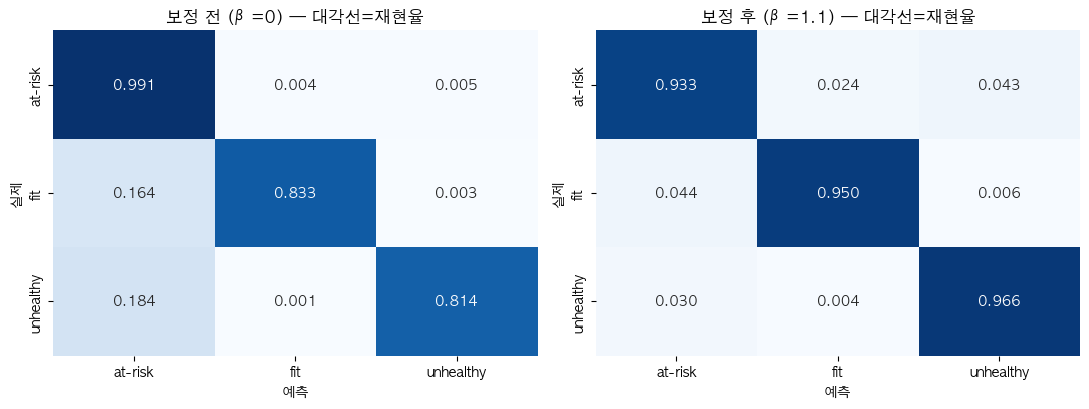

In [43]:
# β 보정이 재현율을 어떻게 재분배하나 — 보정 전/후 클래스별 재현율
import seaborn as sns
from sklearn.metrics import confusion_matrix
names = ["at-risk", "fit", "unhealthy"]   # le 알파벳순 = 0,1,2
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, (title, pred) in zip(axes, [("보정 전 (β=0)", oof_proba.argmax(1)),
                                     ("보정 후 (β=1.1)", (oof_proba / prior ** 1.1).argmax(1))]):
    cm = confusion_matrix(y_enc, pred, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues", vmin=0, vmax=1,
                xticklabels=names, yticklabels=names, ax=ax, cbar=False)
    ax.set_title(f"{title} — 대각선=재현율"); ax.set_ylabel("실제"); ax.set_xlabel("예측")
plt.tight_layout(); plt.show()

+0.07의 정체가 이 두 그림이다. β 보정은 at-risk 재현율을 0.991 → 0.933으로 일부러 깎고(다수라 좀 놓쳐도 됨) 대신 fit 0.833 → 0.950, unhealthy 0.814 → 0.966으로 크게 끌어올린다. 세 재현율의 평균이 balanced accuracy라, 이미 높은 하나를 조금 희생해 낮은 둘을 많이 올리면 평균(0.879 → 0.950)이 뛴다.

In [44]:
# 최종 제출: 전체 데이터로 한 번 학습 → test 확률 → β=1.1 보정
BETA = 1.1
xgb_pipeline.fit(X, y_enc)   # 검증 끝났으니 전체 train으로 재학습 (XGB라 약 5초)

test_raw = pd.read_csv("test.csv")
X_test = test_raw[categorical_cols + numeric_cols]
test_proba = xgb_pipeline.predict_proba(X_test)
pred_beta = (test_proba / (prior ** BETA)).argmax(axis=1)   # β 보정

submission = pd.DataFrame({"id": test_raw["id"], "health_condition": le.inverse_transform(pred_beta)})
submission.to_csv("submission_beta.csv", index=False)
print("보정 후 예측 분포:", submission["health_condition"].value_counts().to_dict())

보정 후 예측 분포: {'at-risk': 238814, 'unhealthy': 34804, 'fit': 22135}


### 결과 — 0.94923, OOF 예측과 일치

캐글 실제 점수 **0.94923**. OOF가 예측한 0.9494와 차이 0.00017로 거의 일치했다.

보정은 예측 분포도 의도대로 바꿨다: at-risk 259,410 → 238,814(−20,596), fit 15,227 → 22,135(+6,908), unhealthy 21,116 → 34,804(+13,688). 소수 클래스를 더 많이 예측하도록 답을 민 것이다.

이 대회 내내 세 번 데였던 검증 ≠ 실제가 여기선 맞아떨어졌다. 이유는 OOF를 누수 없이 만들어 우리 검증이 리더보드를 잘 예측했기 때문이다. 다만 최종 순위는 사설(private)이고, β도 최고값 선택이라 실제가 OOF(0.9494)보다 살짝 아래로 나오는 건 오히려 예상된 방향이다.

기존 최고 0.87828 → **0.94923**. 단 +0.07의 정확한 기준선은 0.87828이 아니다. 0.87828은 네이티브 XGB, β 결과는 원핫 파이프라인 XGB라 서로 다른 모델이다. 파이프라인을 일관되게 맞춘 기준선은 raw OOF **0.8796**이고, 거기서 0.8796 → 0.9494 (+0.0698)가 정직한 도약 폭이다. 어느 쪽이든 핵심은 같다. 모델 교체가 아니라 결정 규칙 하나로 얻은 결과.

**최고점 각주 — 0.94967은 어디서 왔나.** 이 뒤(§10)에서 Optuna로 XGB를 튜닝하고 β=1.0을 얹어 한 번 더 제출했더니 0.94967이 나왔다. 기록상 우리 최고 공개 점수다. 하지만 0.94923(무튜닝 β=1.1)보다 +0.00044일 뿐이다 — LB 점수 한 개씩의 차이라 유의성은 따질 수 없고(§11 표 캡션과 같은 기준), 크기 자체도 CV 흔들림 폭(±0.0018)에 못 미친다. 즉 최고점이 튜닝에서 나온 게 아니라 같은 실력 위에서 운으로 살짝 흔들린 것으로, §10이 '튜닝은 노이즈'라 결론낸 것과 정확히 같은 이야기다. 그래서 이 노트북은 두 값을 사실상 같은 0.949로 본다.

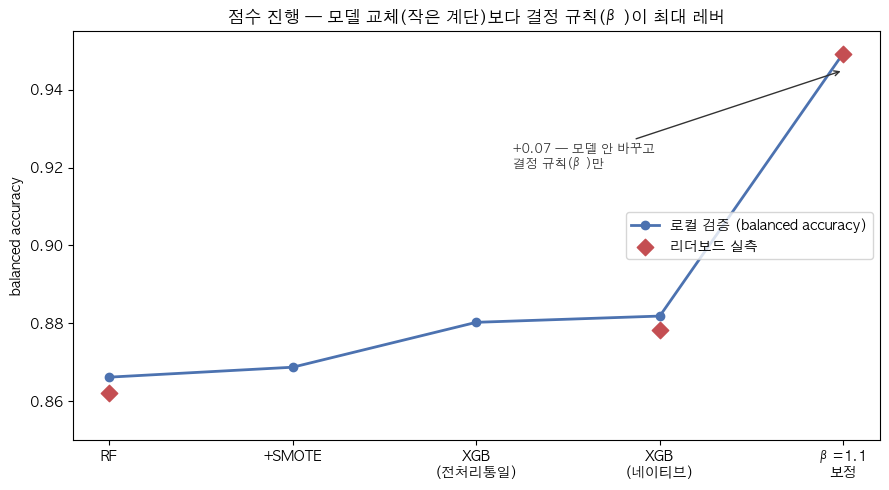

In [45]:
# 점수 진행 곡선 — 이 대회의 전체 아크 (balanced accuracy 단일 축)
stages = ["RF", "+SMOTE", "XGB\n(전처리통일)", "XGB\n(네이티브)", "β=1.1\n보정"]
val = [bal_rf, bal_smote, bal_xgb, bal_xgb_native, 0.9494]   # 앞에서 실측한 로컬 검증값 + β OOF
lb_x, lb_y = [0, 3, 4], [0.86217, 0.87828, 0.94923]         # 제출한 지점의 리더보드 실측

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(5), val, "o-", color="#4C72B0", lw=2, label="로컬 검증 (balanced accuracy)")
ax.scatter(lb_x, lb_y, marker="D", s=70, color="#C44E52", zorder=5, label="리더보드 실측")
ax.annotate("+0.07 — 모델 안 바꾸고\n결정 규칙(β)만", xy=(4, 0.945), xytext=(2.2, 0.92),
            color="#333", fontsize=9, arrowprops=dict(arrowstyle="->", color="#333"))
ax.set_xticks(range(5)); ax.set_xticklabels(stages)
ax.set_ylim(0.85, 0.955); ax.set_ylabel("balanced accuracy")
ax.set_title("점수 진행 — 모델 교체(작은 계단)보다 결정 규칙(β)이 최대 레버")
ax.legend(loc="center right")
plt.tight_layout(); plt.show()

## 10. 천장 — 넘을 수 있나, 그리고 왜 여기가 끝인가

0.95을 목표로 두 가지를 봤다. (1) 8가지 방법으로 더 올릴 수 있나(천장 탐색), (2) 애초에 이 천장의 정체가 무엇인가(확률 보정·생성규칙 역설계). 결론부터 말하면 8가지로는 ~0.95를 못 넘었다. 정체는 처음엔 데이터 노이즈라 봤는데, 재검증에서 그 결론이 틀렸다(아래 정정).

### 공개 리더보드 실측
`kaggle competitions leaderboard`로 1,549팀을 받아 보니 1등 0.95182, 우리(0.94923)보다 위가 758팀, 0.95를 넘긴 팀이 406개다. 우리는 천장이 아니라 천장 근처의 중위권이다. 1등이 0.003 위에 있으니 위로 자리는 있다. 다만 이건 공개 리더보드 점수 한 개씩의 차이라, 그 0.003이 실력 차인지 운인지는 못 가린다. 확실한 건 현 방법들이 ~0.95에서 정체한다는 정황뿐이고, 실용적 정체 구간이 정직한 표현이다(데이터 천장이라 단정하기엔 근거가 부족하다).

### 8가지 시도 — 전부 최종 점수엔 무영향

| 시도 | 효과 (balanced accuracy) |
|---|---|
| 모델 교체(LGBM/CatBoost) | XGB가 최고 — paired로 실재 확인(§8), 단 β 후 수렴 |
| SMOTE (CV로 재측정) | +0.0029 약신호였으나 부스팅에 밀려 미사용 |
| 부스팅 네이티브 처리 | XGB만 +0.0016, 나머지는 악화 |
| 앙상블(XGB+LGB 평균) | +0.0003 (아래 코드) |
| 클래스별 β | +0.0001, 균일 β가 최적 (아래 코드) |
| Optuna 튜닝 | OOF 재현 시 +0.0000 (아래 코드). 제출은 0.94967(LB, 무튜닝 β판 0.94923 대비 +0.0004) — 둘 다 노이즈 |
| 피처 손보기(제거·파생 4개 추가) | −0.0001 (파생 4개는 아래 코드로 실측, 제거는 이전 세션 기록) |
| 최다득표 초복잡 스태킹(kospintr) | 0.950 (외부 노트북, 우리와 0.001 차) |

**복잡함이 점수를 거의 안 올렸다.** 온갖 기법을 다 넣은 최다득표 노트북조차 우리와 0.001 차이. 우리 도구 범위에선 ~0.95가 **실용적 정체 구간**이다.


### 앙상블·튜닝·클래스별 β·파생변수 실측

앙상블·튜닝·클래스별 β는 저장된 OOF와 알려진 파라미터로 측정한다. 파생변수 4개는 규칙 기반으로 만들어 실측한다.

**Optuna**는 손잡이(나무 깊이·학습률 같은 설정값) 조합을 무작위 대신 똑똑하게 탐색해주는 도구다. 탐색 자체는 이전 세션에 돌렸고 여기엔 그때 나온 파라미터만 옮겨 적었다(그 탐색이 왜 헛수고였는지는 §10 교훈 3).

β와 목적이 같은 다른 방법도 이어서 측정한다 — `class_weight`(학습할 때 소수 클래스를 틀리면 벌점을 더 주는 것)를 β와 겹쳐 쓰면 어떻게 되나.

In [46]:
# 앙상블·튜닝·클래스별 β — 저장된 OOF와 알려진 파라미터로 실측
import numpy as np
from sklearn.model_selection import cross_val_predict

prior = np.bincount(y_enc) / len(y_enc)
def bscore(p, b=1.0):
    return balanced_accuracy_score(y_enc, (p / prior**b).argmax(axis=1))

oof_lgb = cross_val_predict(lgbm_pipeline, X, y_enc, cv=cv, method="predict_proba")   # 앙상블용
tuned = Pipeline([("전처리", preprocessor),                                            # Optuna가 찾은 파라미터
                  ("모델", XGBClassifier(n_estimators=240, learning_rate=0.032, max_depth=7,
                                        random_state=42, n_jobs=-1, tree_method="hist"))])
oof_tuned = cross_val_predict(tuned, X, y_enc, cv=cv, method="predict_proba")

base = bscore(oof_proba)
print(f"무튜닝 XGB + β=1.0 (기준):  {base:.4f}")
print(f"앙상블 XGB+LGB:            {bscore((oof_proba + oof_lgb) / 2) - base:+.4f}")
print(f"튜닝 XGB:                  {bscore(oof_tuned) - base:+.4f}")
best = max(bscore(oof_proba, np.array([a, f, u])) for a in [.9, 1, 1.1] for f in [.9, 1, 1.1] for u in [.9, 1, 1.1])
print(f"클래스별 β 최적:            {best - base:+.4f}  (균일 β=1.0이 최적)")


무튜닝 XGB + β=1.0 (기준):  0.9494
앙상블 XGB+LGB:            +0.0003
튜닝 XGB:                  +0.0000


클래스별 β 최적:            +0.0001  (균일 β=1.0이 최적)


In [47]:
# class_weight × β 병용 실측 — 학습 때 벌점(class_weight)과 예측 때 β를 겹치면 과보정되나
# (교훈2의 '0.9494→0.876' 근거. sklearn 1.6+ 메타데이터 라우팅 우회 위해 수동 5폴드 루프)
import numpy as np
from sklearn.utils.class_weight import compute_sample_weight
oof_cw = np.zeros_like(oof_proba)
for tr_idx, va_idx in cv.split(X, y_enc):
    sw = compute_sample_weight('balanced', y_enc[tr_idx])
    xgb_cw = Pipeline([('전처리', preprocessor), ('모델', XGBClassifier(random_state=42, n_jobs=-1))])
    xgb_cw.fit(X.iloc[tr_idx], y_enc[tr_idx], **{'모델__sample_weight': sw})
    oof_cw[va_idx] = xgb_cw.predict_proba(X.iloc[va_idx])
print('class_weight 없이 β=1.1:', round(bscore(oof_proba, 1.1), 4))
print('class_weight + β=1.1  :', round(bscore(oof_cw, 1.1), 4), '  <- 과보정(β와 겹쳐 악화 확인)')

class_weight 없이 β=1.1: 0.9494
class_weight + β=1.1  : 0.876   <- 과보정(β와 겹쳐 악화 확인)


### 파생변수

넣은 피처는 이 절 뒤 '생성규칙 역설계'에서 거꾸로 찾은 규칙이다(규칙을 어떻게 도출했는지는 아래 참고): 잠×스트레스(unhealthy 규칙), 잠×활동과 잠×(2−스트레스)×활동(fit 규칙).

In [48]:
# 파생변수(피처엔지니어링) 실측 — 역설계 규칙을 손피처로 넣어도 오르나?
# stress/activity를 순서값으로 (low/sedentary=0 … high/active=2)
stress_ord = X['stress_level'].map({'low': 0, 'medium': 1, 'high': 2})
act_ord    = X['physical_activity_level'].map({'sedentary': 0, 'moderate': 1, 'active': 2})

X_fe = X.copy()
X_fe['fe_sleep_x_stress']    = X['sleep_duration'] * stress_ord              # unhealthy: 잠<6 & 고스트레스
X_fe['fe_sleep_x_activity']  = X['sleep_duration'] * act_ord                # fit 규칙 일부
X_fe['fe_stress_x_activity'] = stress_ord * act_ord
X_fe['fe_fit_score']         = X['sleep_duration'] * (2 - stress_ord) * act_ord   # fit 규칙 통째로
fe_cols = ['fe_sleep_x_stress', 'fe_sleep_x_activity', 'fe_stress_x_activity', 'fe_fit_score']

# 파생피처를 숫자형에 포함시킨 전처리기로 XGB OOF 재계산 (같은 cv)
prep_fe = ColumnTransformer([("범주형", categorical_pipeline, categorical_cols),
                             ("숫자형", numeric_pipeline, numeric_cols + fe_cols)])
xgb_fe = Pipeline([("전처리", prep_fe), ("모델", XGBClassifier(random_state=42, n_jobs=-1))])
oof_fe = cross_val_predict(xgb_fe, X_fe, y_enc, cv=cv, method="predict_proba")

def best_beta(p):   # β를 훑어 최고 balanced accuracy
    return max(balanced_accuracy_score(y_enc, (p / prior**b).argmax(1))
               for b in [0, .3, .5, .7, .9, 1, 1.1, 1.2, 1.5])

print(f"무FE (기준):   {best_beta(oof_proba):.4f}")
print(f"파생피처 4개:  {best_beta(oof_fe):.4f}")
print(f"Δ = {best_beta(oof_fe) - best_beta(oof_proba):+.4f}")

무FE (기준):   0.9494


파생피처 4개:  0.9493


Δ = -0.0001


정답 규칙을 통째로 떠먹여줘도 0.9494 → 0.9493으로, Δ는 −0.0001이다. 이건 §8이 paired로 측정한 폴드별 차이의 흔들림(std ~0.0005) 안이라 0과 구별되지 않는다 — §8이 못박은 대로, 비교에 쓸 자는 각 모델의 marginal std(±0.0018)가 아니라 이쪽이다. 즉 측정 가능한 개선이 없다(부호가 −라고 "나빠졌다"고 읽으면 이 노트북이 내내 경계한 그 오류다).

왜 안 오를까. 일반적으로 부스팅 트리는 잠·스트레스·활동을 각각 들고 분할을 층층이 쌓아 그 상호작용을 스스로 만든다. 그래서 손으로 만든 곱셈 컬럼은 새 정보라기보다 중복이기 쉽다. 다만 이 한 번의 −0.0001이 그 메커니즘을 증명하는 건 아니고, 이 데이터·이 모델에선 파생피처가 측정 가능한 이득을 안 줬다까지가 실측이 말하는 전부다.

파생피처 자체가 쓸모없다는 뜻은 아니다. 선형 모델이었다면 상호작용을 손으로 만들지 않는 한 영영 못 봤을 테니 파생피처가 유일한 통로였을 것이다. 부스팅에 약할 뿐이다.

### 천장의 정체 — 확률 보정과 생성규칙 역설계

위 8가지 탐색은 ~0.95를 실용적 정체 구간이라 불렀지만 두 가지를 유보했다. (1) 결정 규칙의 재료인 확률이 삐뚤어져 손해 보고 있진 않은가, (2) 이 천장의 정체가 무엇인가. 여기서 그 둘을 본다.

> **TL;DR:** 확률은 이미 잘 보정돼 있어 손댈 게 없었다(재료는 깨끗했다, 아래 셀에서 확인). 천장의 정체는 역설계로 규칙을 찾았지만, 처음엔 규칙 밖 노이즈가 천장이라 결론냈다가 재검증에서 그게 틀렸음을 확인했다(3규칙만으론 0.944, 우리는 0.949). 점수는 그대로지만 결론 하나를 바로잡았다.

### 확률 보정(calibration) — 재료는 적어도 다수에선 깨끗했다

결정 규칙(β)은 `확률 / prior^β`로 답을 민다. 확률을 재료로 쓴다. 모델이 90% 확신이라 한 것들이 실제로는 70%만 맞으면(과신), 그 삐뚤어진 확률로 β를 돌리는 셈이라 손해다. 신뢰도 곡선으로 확인한다. 예측 확률을 구간으로 나눠 각 구간의 실제 정답 비율과 비교해, 대각선(예측=실제)에서 벗어나면 삐뚤어진 것이다.

**결과:** 세 클래스 모두 최대 이탈 0.003 이하로 점들이 대각선에 붙는다. 단, 이 결론엔 한계가 있다. 표본이 몰린 다수 클래스(at-risk 86%)가 이탈 수치를 지배하는데, 정작 balanced accuracy를 가르는 건 fit·unhealthy다. 그 소수 클래스는 확률이 높은 구간에 표본이 적어 보정 상태를 거칠게밖에 못 측정한다. 그러니 다수 클래스는 잘 보정됐다까지가 확실하고, 소수 클래스는 미확정으로 남긴다. calibration이 점수를 안 올린 것도 실측이 아니라 곡선에서의 추론이다(이미 정확하면 보정해도 안 변한다는 논리). 그래도 β의 재료가 최소한 다수 쪽에서 삐뚤지 않았음을 확인한 진단으로는 성공이다.

at-risk    최대이탈=0.0028
fit        최대이탈=0.0010
unhealthy  최대이탈=0.0015


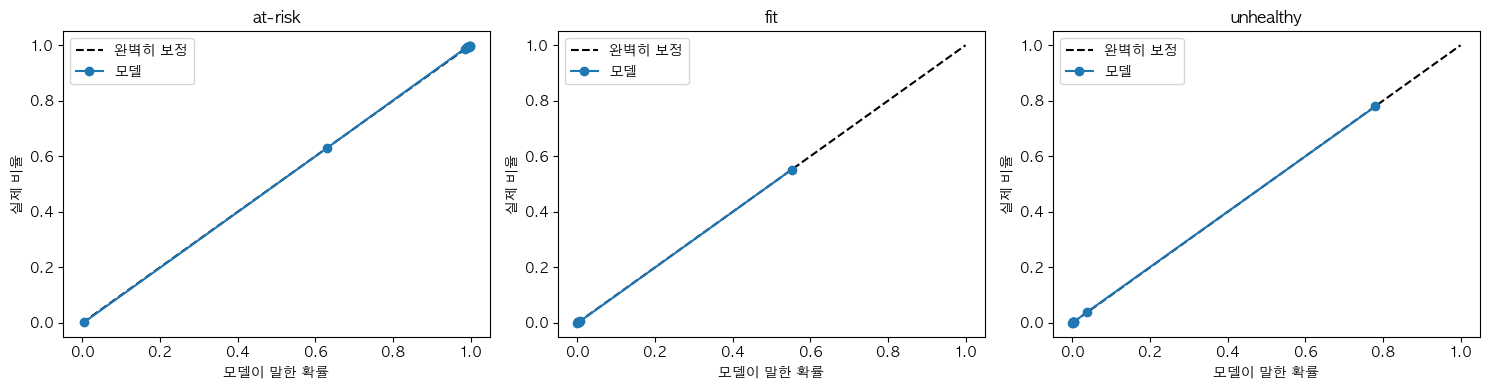

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# §8에서 저장한 (무튜닝) XGB의 OOF 확률 — §9의 β가 실제로 먹인 재료다 (모델 재학습 없음)
oof = np.load('oof_proba.npy')   # (690088, 3)
y   = np.load('y_enc.npy')
names = ['at-risk', 'fit', 'unhealthy']

# 3클래스라 각 클래스를 one-vs-rest로: '이게 클래스 k일 확률' vs '실제로 k였나'
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for k, ax in enumerate(axes):
    frac_pos, mean_pred = calibration_curve((y == k).astype(int), oof[:, k], n_bins=10, strategy='quantile')
    ax.plot([0, 1], [0, 1], 'k--', label='완벽히 보정')
    ax.plot(mean_pred, frac_pos, 'o-', label='모델')
    ax.set_title(names[k]); ax.set_xlabel('모델이 말한 확률'); ax.set_ylabel('실제 비율'); ax.legend()
    print(f'{names[k]:10s} 최대이탈={np.abs(frac_pos - mean_pred).max():.4f}')
plt.tight_layout(); plt.show()


### 생성규칙 역설계

위 탐색은 라벨 노이즈를 직접 재지 않아 천장 확증은 과하다고 유보했다. 그 노이즈를 재려면 먼저 타깃이 어떻게 만들어졌는지를 알아야 한다. Playground 합성 데이터는 보통 규칙으로 라벨을 붙이고 일부를 무작위로 뒤섞어(노이즈) 만든다(§2의 합성 지문이 그 증거였다). model-free 중요도 1·2·3등이 sleep·stress·activity였으니, 이 셋으로 규칙을 거꾸로 확보했다.

**sleep 하나만으로도 계단이 보였다.** 임계값 규칙의 지문이다. 완만한 곡선이 아니라 특정 값에서 타깃 비율이 점프했다. sleep≈6에서 unhealthy가 급락, sleep≈7에서 fit이 급증. 다만 sleep<6에서도 unhealthy는 39%뿐(나머지는 at-risk)이라 두 번째 축이 필요했고, stress·activity를 겹쳐 규칙을 완성했다.

In [50]:
import pandas as pd

tr = pd.read_csv('train.csv')
d = tr[['sleep_duration', 'stress_level', 'physical_activity_level', 'health_condition']].dropna()

# sleep × stress 격자에서 unhealthy 비율 (계단이 어디서 꺾이나)
d['sleep_g'] = pd.cut(d['sleep_duration'], [0, 6, 7, 100], labels=['잠<6', '6~7', '잠>7'])
print('=== unhealthy 비율 (sleep × stress) ===')
print(d.pivot_table(index='stress_level', columns='sleep_g', values='health_condition',
                    aggfunc=lambda x: (x == 'unhealthy').mean(), observed=True).round(3))

# fit의 세 번째 축: 잠>7 & 스트레스 low 에서 activity별 fit 비율
fitgrp = d[(d.sleep_duration > 7) & (d.stress_level == 'low')]
print('\n=== fit 비율 (잠>7 & 스트레스low, activity별) ===')
print(fitgrp.groupby('physical_activity_level')['health_condition'].apply(lambda x: (x == 'fit').mean()).round(3))
# 결과: unhealthy = 잠<6 & 스트레스high (98.4%) / fit = 잠>7 & 스트레스low & 운동active (99.1%)

=== unhealthy 비율 (sleep × stress) ===
sleep_g         잠<6    6~7    잠>7
stress_level                     
high          0.984  0.014  0.002
low           0.003  0.002  0.003
medium        0.005  0.002  0.003

=== fit 비율 (잠>7 & 스트레스low, activity별) ===
physical_activity_level
active       0.991
moderate     0.002
sedentary    0.002
Name: health_condition, dtype: float64


**생성 규칙:**

```
unhealthy = 잠<6  AND  스트레스 high                  → 98.4%
fit       = 잠>7  AND  스트레스 low  AND  운동 active   → 99.1%
at-risk   = 나머지 전부 (기본값)
```

세 피처의 조합으로 타깃이 거의 결정됐다. 규칙이 깔끔한데도 100%가 아니라 98~99%다. 처음엔 이 남은 1~2%를 규칙 밖 라벨 노이즈로 보고, 그게 곧 천장이라고 결론냈다.

**그런데 이건 성급했다.** 98~99%는 규칙 셀 *안에서만* 측정한 순도다. 규칙 밖 노이즈가 최대 점수의 한계라는 건 별개 주장이고, 재보기 전엔 확정이 아니다. 3규칙 피처만으로 낼 수 있는 최대 점수를 직접 측정한다.

### 재검증 — 3규칙이 천장인가

3규칙 피처(sleep·stress·activity)만으로 낼 수 있는 최대 점수를 측정한다. 데이터를 반으로 갈라, A로 각 피처 조합(셀)의 최적 클래스를 정하고 B에서 채점한다(누수 없음). 이렇게 데이터를 반 떼어 그 위에서 채점하는 방식을 held-out(떼어놓고 시험)이라 한다. sleep은 연속값이라 구간으로 나누는데, 촘촘히 나눌수록 규칙의 임계값을 더 잘 잡는다. 이 값이 우리 0.949와 같으면 3규칙이 천장이고, 낮으면 다른 피처가 신호를 더 준다는 뜻이다.


In [51]:
# 재검증: "천장 = 3규칙 밖 노이즈"가 맞나 — 3규칙 피처만의 최대 점수를 잰다.
# 데이터를 반으로 갈라 A로 셀별 최적 클래스를 정하고 B에서 채점(누수 없음).
# 셀별 최적 클래스 = 확률/prior 의 argmax = balanced accuracy 최적(모델의 β와 같은 자).
# sleep 구간(bin)을 늘리며 5시드 평균 → 천장이 어디서 정점을 찍는지 본다.
import numpy as np, pandas as pd
from sklearn.metrics import balanced_accuracy_score

tr = pd.read_csv('train.csv')
classes = ['at-risk', 'fit', 'unhealthy']
y = tr['health_condition'].values
prior = pd.Series(y).value_counts(normalize=True).reindex(classes).values

def ceiling(sleep_bins, seed):
    rng = np.random.RandomState(seed)
    idx = rng.permutation(len(tr)); A, B = idx[:len(tr)//2], idx[len(tr)//2:]
    sb = pd.qcut(tr['sleep_duration'].rank(method='first'), sleep_bins, labels=False).fillna(-1).astype(int).astype(str)
    cell = (sb + '|' + tr['stress_level'].fillna('na').astype(str)
               + '|' + tr['physical_activity_level'].fillna('na').astype(str)).values
    counts = (pd.DataFrame({'c': cell[A], 'y': y[A]}).groupby(['c', 'y']).size()
              .unstack(fill_value=0).reindex(columns=classes, fill_value=0))
    best = pd.Series([classes[i] for i in (counts.values / counts.values.sum(1, keepdims=True) / prior).argmax(1)],
                     index=counts.index)
    return balanced_accuracy_score(y[B], pd.Series(cell[B]).map(best).fillna('at-risk').values)

for b in [10, 30, 50, 100, 200]:
    vals = [ceiling(b, s) for s in [0, 1, 2, 42, 7]]
    print(f"3규칙, sleep {b:3d}구간: 천장 {np.mean(vals):.4f}  (std {np.std(vals):.4f})")
print("우리 XGB+β (13피처 전부):  0.9494")

3규칙, sleep  10구간: 천장 0.9375  (std 0.0004)


3규칙, sleep  30구간: 천장 0.9427  (std 0.0005)


3규칙, sleep  50구간: 천장 0.9437  (std 0.0005)


3규칙, sleep 100구간: 천장 0.9437  (std 0.0006)


3규칙, sleep 200구간: 천장 0.9433  (std 0.0005)
우리 XGB+β (13피처 전부):  0.9494


### 정정 — 천장은 3규칙 노이즈가 아니다

3규칙 피처만의 천장은 약 0.944다. sleep 구간을 늘리면 bin 50~100에서 0.944로 정점을 찍고, 더 촘촘히 하면 셀이 성겨져 오히려 다시 내려간다(5시드 std 0.0005). 이 정점 후 하락이 held-out 측정이 제대로 작동한다는 신호다. 우리 모델은 13피처를 다 써서 0.949로, 3규칙 천장을 근소하게 넘는다(갭 0.006 ≈ 천장 노이즈의 10배 이상).

- **천장이 규칙 밖 1~2% 노이즈, 즉 베이즈 오차(누구도 못 넘는 이론상 최고점)라는 생각은 틀렸다.** 3규칙이 신호의 대부분(0.944)을 잡지만 전부는 아니다. 나머지 피처가 +0.005를 더 준다(단, 이 신호는 손규칙으로는 못 짜내고 XGB가 셀을 매끄럽게 이어 써서 얻는다 — 아래에서 확인).
- **13피처 전부의 진짜 베이즈 천장은 이 방법으론 못 측정한다.** 피처를 더 넣으면 셀이 성겨져 추정이 무너진다. 0.949가 그 천장인지, 위가 더 있는지는 미결이다.
- **정직한 이름은 실용적 정체 구간이지 증명된 베이즈 천장이 아니다.** 역설계로 얻은 건 천장의 값이 아니라 소수 클래스를 지배하는 규칙이다.

### 4번째 규칙이 있나 — 안 걸린 나머지

정정했지만 하나가 남는다. 3규칙에 안 걸리는 나머지에 4번째 규칙이 있을 수 있다. 규칙 2개에 안 걸리는 나머지(89.5%)를 봤더니 이 중 4.2%가 at-risk가 아닌 fit·unhealthy 오염이다.

무엇이 그 오염을 가르나 봤더니 신호는 있었다. 나머지 안에서 fit은 step_count가 높고(11346 vs 8500) 운동량·sleep_quality도 좋다. 생성 규칙은 하드 3규칙이 아니라 활동·수면질까지 쓰는 graded 규칙으로 보인다. 그런데 이 피처들을 셀 천장에 더해도 0.949를 못 넘는다:

In [52]:
# 4번째 규칙 찾기: 안 걸린 나머지를 가르는 피처(sleep_quality·step_count 등)를
# 셀 천장에 더하면 0.949를 넘나 — 재검증과 같은 held-out 방식
np.random.seed(42)
idx = np.random.permutation(len(tr)); A, B = idx[:len(tr)//2], idx[len(tr)//2:]

def cell_ceiling(parts):
    cell = parts[0]
    for p in parts[1:]:
        cell = cell + '|' + p
    cell = cell.values
    counts = (pd.DataFrame({'c': cell[A], 'y': y[A]}).groupby(['c', 'y']).size()
              .unstack(fill_value=0).reindex(columns=classes, fill_value=0))
    best = pd.Series([classes[i] for i in (counts.values / counts.values.sum(1, keepdims=True) / prior).argmax(1)],
                     index=counts.index)
    return balanced_accuracy_score(y[B], pd.Series(cell[B]).map(best).fillna('at-risk').values)

sd = pd.qcut(tr['sleep_duration'].rank(method='first'), 30, labels=False).fillna(-1).astype(int).astype(str)
st, pa, sq = tr['stress_level'].fillna('na').astype(str), tr['physical_activity_level'].fillna('na').astype(str), tr['sleep_quality'].fillna('na').astype(str)
stp = pd.qcut(tr['step_count'].rank(method='first'), 6, labels=False).fillna(-1).astype(int).astype(str)

print("3규칙만:                 ", round(cell_ceiling([sd, st, pa]), 4))
print("+ sleep_quality:         ", round(cell_ceiling([sd, st, pa, sq]), 4))
print("+ sleep_quality + step:  ", round(cell_ceiling([sd, st, pa, sq, stp]), 4))
print("우리 XGB+β (13피처):      0.949")


3규칙만:                  0.9429


+ sleep_quality:          0.943


+ sleep_quality + step:   0.9379
우리 XGB+β (13피처):      0.949


sleep_quality를 더해도 +0.0001(노이즈)이고, step_count까지 넣으면 오히려 떨어진다. 신호는 있지만 규칙으로는 못 짜낸다. XGB는 셀을 매끄럽게 이어 봐서 이 신호를 이미 다 쓰고 있다. 안 걸린 나머지에 구조는 있으나 손규칙이 모델을 못 이긴다. 0.949 위는 손규칙이 아니라 더 나은 모델의 몫이고, 그건 앞 8가지 탐색에서 노이즈로 확인한 영역이다.

### 방법론 교훈 — 그리고 벽의 정체

**두 유보가 풀렸다. 하나는 예상과 다르게.** 확률은 이미 깨끗했고(calibration 무효 = 재료 탓 아님), 천장의 정체는 처음 생각한 규칙 밖 노이즈가 아니었다. 3규칙은 신호의 대부분(0.944)을 설명하지만 우리 0.949는 그걸 넘는다. 0.949가 못 넘는 진짜 이유는 미결이다. 규칙(대부분 설명)도, 모델(3모델 동급)도, 결정 규칙(β=1 이론 최적)도, 재료(확률 보정 완료)도 아니지만, 데이터 노이즈가 벽이라고 단정할 근거도 재보니 부족했다.

**단 이건 데이터 천장이 아니다.** 공개 리더보드에서 406팀이 0.95를 넘었고 1등은 0.952다. 남들이 넘었으니 못 넘을 벽이 아니라 우리 도구로 못 넘은 벽이다. 그래서 여기서 멈추는 이유는 천장이라서가 아니라, 그 위가 배움 대비 순위 노이즈라서다.

이 대회에서 진짜 배운 방법론 7가지:

1. **CV로 노이즈 판별:** 올랐다를 믿기 전에 흔들림 폭과 비교한다. +0.0001은 개선이 아니라 측정 오차다. *paired 비교*(같은 폴드에서 A·B를 나란히 재기)를 쓰면 폴드 운이 상쇄돼 순수 차이만 보인다.
2. **class_weight = β 보정의 형제:** 학습 때 소수 클래스에 벌점(class_weight) vs 예측 때 확률 나눗셈(β). 같은 목적이라 하나만 써야 한다. 둘 다 쓰면 과보정된다(0.9494 → 0.8760, 실측).
3. **베이지안 튜닝(Optuna)의 함정:** 손잡이를 똑똑하게 탐색하지만, ① 10만 샘플에서 좋아 보인 게 전체에선 사라졌고(+0.0025→+0.0000, §10 OOF 재현 — LB 제출 차 +0.0004도 노이즈) ② 25번 시도 중 최고를 고른 optimistic bias가 껴 있었다(이 세 수치 10만·+0.0025·25는 이전 세션 Optuna 런 기록이고, 탐색 코드 자체는 이 노트북엔 없다). 샘플은 전체가 아니고, 최고값은 진짜가 아니다. 반드시 전체로 재검증한다.
4. **공개 ≠ 사설(private) 리더보드:** 공개 점수를 좇아 오버핏하면 사설(최종)에서 무너진다. 정직한 CV 검증이 일반화이자 사설 승리다. 사설 순위는 아직 모르지만, 공개 LB의 미세 우위를 좇지 않는 게 일반적으로 안전하다.
5. **결정 규칙 보정이 곧 베이지안이다**(§9 참고). 확률을 prior로 나눈 것 = 사전확률 편향 제거 = 베이즈 분류기.
6. **calibration은 점수 카드가 아니라 진단 도구다.** 확률이 이미 정확하면 보정해도 점수는 그대로지만, β의 재료(확률)가 삐뚤지 않았나를 확인해주는 진단으로는 성공이다.
7. **규칙 셀 순도 ≠ 천장.** 소수 클래스 규칙 셀이 98~99% 순수해도 그게 곧 최대 점수 99%라는 뜻은 아니다. 3규칙 피처만의 실제 천장은 0.944였고 우리는 그걸 넘었다. 규칙 밖 노이즈가 베이즈 오차라 단정하기 전에 직접 재야 한다. 처음엔 이걸 건너뛰고 과대주장했다.

> **오늘의 핵심:** 점수가 안 오를 때 물을 것은 뭘 더 할까가 아니라 이게 천장인가다. 그리고 천장이라는 답이 나오면 그게 진짜인지 재본다 — 이번엔 재보니 천장이 아니었다.

## 11. 마무리

### 최종 종합 비교표 — 시도한 모든 것, 최종 선택 = XGBoost + β 보정

실험한 모든 모델을 정확한 값으로 한 표에 모았다. 로컬은 balanced accuracy(§6은 단일 holdout, §8~10은 CV/OOF), 리더보드(LB)는 실제 제출 점수다.

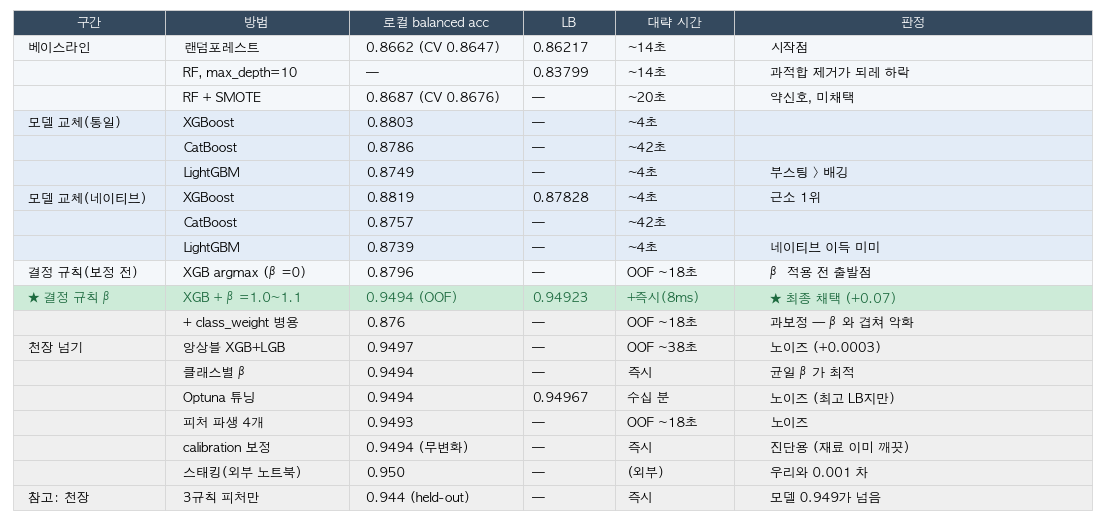

In [53]:
# 최종 종합 비교표 (그림) — 시도한 모든 모델 + 대략 계산 시간.
# 점수는 §5~§10에서 실측한 값 모음. 시간 = 이 맥북서 perf_counter 실측(모델 4종 full-data 1회: RF~14·XGB~4·LGB~4·CatBoost~42초), OOF는 5폴드라 ~5배·후처리는 즉시.
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"; plt.rcParams["axes.unicode_minus"] = False

# (구간, 방법, 로컬, 리더보드, 대략 시간, 판정, 범주)
rows = [
    ("베이스라인",       "랜덤포레스트",         "0.8662 (CV 0.8647)", "0.86217", "~14초",       "시작점",              "base"),
    ("",                "RF, max_depth=10",    "—",                  "0.83799", "~14초",       "과적합 제거가 되레 하락",  "base"),
    ("",                "RF + SMOTE",          "0.8687 (CV 0.8676)", "—",       "~20초",       "약신호, 미채택",        "base"),
    ("모델 교체(통일)",   "XGBoost",             "0.8803",             "—",       "~4초",        "",                   "model"),
    ("",                "CatBoost",            "0.8786",             "—",       "~42초",       "",                   "model"),
    ("",                "LightGBM",            "0.8749",             "—",       "~4초",        "부스팅 > 배깅",         "model"),
    ("모델 교체(네이티브)","XGBoost",            "0.8819",             "0.87828", "~4초",        "근소 1위",             "model"),
    ("",                "CatBoost",            "0.8757",             "—",       "~42초",       "",                   "model"),
    ("",                "LightGBM",            "0.8739",             "—",       "~4초",        "네이티브 이득 미미",     "model"),
    ("결정 규칙(보정 전)", "XGB argmax (β=0)",    "0.8796",             "—",       "OOF ~18초",   "β 적용 전 출발점",       "base"),
    ("★ 결정 규칙 β",    "XGB + β=1.0~1.1",     "0.9494 (OOF)",       "0.94923", "+즉시(8ms)",  "★ 최종 채택 (+0.07)",   "winner"),
    ("",                "+ class_weight 병용",  "0.876",              "—",       "OOF ~18초",   "과보정 — β와 겹쳐 악화",   "noise"),
    ("천장 넘기",        "앙상블 XGB+LGB",       "0.9497",             "—",       "OOF ~38초",   "노이즈 (+0.0003)",      "noise"),
    ("",                "클래스별 β",           "0.9494",             "—",       "즉시",        "균일 β가 최적",         "noise"),
    ("",                "Optuna 튜닝",         "0.9494",             "0.94967", "수십 분",     "노이즈 (최고 LB지만)",    "noise"),
    ("",                "피처 파생 4개",        "0.9493",             "—",       "OOF ~18초",   "노이즈",              "noise"),
    ("",                "calibration 보정",     "0.9494 (무변화)",     "—",       "즉시",        "진단용 (재료 이미 깨끗)",  "noise"),
    ("",                "스태킹(외부 노트북)",    "0.950",              "—",       "(외부)",      "우리와 0.001 차",       "noise"),
    ("참고: 천장",       "3규칙 피처만",         "0.944 (held-out)",   "—",       "즉시",        "모델 0.949가 넘음",     "noise"),
]
cols = ["구간", "방법", "로컬 balanced acc", "LB", "대략 시간", "판정"]
CBG = {"base": "#F4F7FA", "model": "#E3ECF7", "winner": "#CDEBD8", "noise": "#EFEFEF"}

fig, ax = plt.subplots(figsize=(14, 6.5))
ax.axis("off")
tbl = ax.table(cellText=[r[:6] for r in rows], colLabels=cols,
               colWidths=[0.14, 0.17, 0.16, 0.085, 0.11, 0.33], loc="center", cellLoc="left")
tbl.auto_set_font_size(False); tbl.set_fontsize(9.2); tbl.scale(1, 1.5)

for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor("#D6D6D6"); cell.set_linewidth(0.6)
    if r == 0:
        cell.set_facecolor("#34495E"); cell.get_text().set_color("white"); cell.get_text().set_fontweight("bold")
    else:
        cat = rows[r - 1][6]
        cell.set_facecolor(CBG[cat])
        if cat == "winner":
            cell.get_text().set_fontweight("bold"); cell.get_text().set_color("#1d6b3f")

plt.show()

**표에서 짚을 것 — 더 높은 점수가 왜 실력이 아닌가.** 로컬 최고점은 앙상블 0.9497, 제출 최고점은 튜닝 0.94967로 채택값(0.9494 / LB 0.94923)보다 높다. 그런데 로컬 차이(+0.0003)는 §8 paired 기준으로 노이즈이고(§8은 비교엔 marginal ±0.0018이 아니라 폴드별 부호 일관성과 효과 크기를 쓰라고 못박았다), LB 차이(+0.0004)는 공개 리더보드 점수가 한 개씩이라 유의한지 자체를 못 따진다. 어느 쪽도 실력 차로 볼 근거가 없다. 공개 LB의 이런 미세 우위를 좇아 최댓값을 고르면 정직한 검증엔 안 잡히는 운을 사는 셈이라 사설(최종) 순위에서 무너진다(공개 ≠ 사설). 같은 실력이면 제일 단순하고 재현·설명이 쉬운 걸 고르는 게 정석이다.

### 그래서 무엇을 골랐나

위 비교표가 이 대회의 전부다(표의 '대략 시간'은 자릿수 비교용 어림치이고 정밀 측정은 아니다). 모델을 8가지로 갈아끼워도 0.87~0.88 좁은 띠에 뭉쳤고(모델 교체는 레버가 아니었다), β 이후 6가지를 더 시도해도 전부 0.949 노이즈 띠 안이었다. 유일하게 그 띠를 벗어난 건 β 결정 규칙(+0.07)이다. 그래서 최종 모델은 **XGBoost + β 보정**이다.

### 배운 것

1. **로컬 검증은 리더보드와 같은 지표로 측정한다.** 96%(accuracy)로 좋아 보인 게 실제 86%(balanced accuracy)였던 건 실력이 아니라 검증 기준이 달랐던 것이다. 기준을 맞추자 로컬이 리더보드를 예측했다(OOF 0.9494 ≈ 실제 0.94923).
2. **최대 레버는 모델이 아니라 답 고르는 규칙(β, +0.07).** 채점 지표에 결정 규칙을 맞춘 것이다.

3. **결론은 계통적으로 얻었다.** 10%p 미스터리를 반증 가능한 가설 4개로 하나씩 falsify하고(§5), RF 중요도 편향을 model-free 효과크기로 교차검증하고(§4), 모델 비교는 paired로 폴드 운을 걷어냈다(§8). 숫자 하나하나를 노이즈 폭과 대보며 '올랐다'를 의심한 것.

CV·paired 비교·calibration·베이지안 등 방법론 세부는 §10 방법론 교훈에 정리했다.

### 안 통한 것, 작았던 것

- max_depth=10(과적합 제거): 실제 0.83799로 오히려 하락.
- SMOTE: +0.25%p. CV로 측정하니 약한 신호였으나 부스팅에 밀려 미사용.
- 부스팅 3종 순위: paired 검정으로 XGB > CatBoost > LGBM은 실재하지만(§8), β 보정 후엔 ~0.95로 수렴할 것으로 보여(β 실측은 XGB만, §8) 결과엔 무영향이다. 실재하지만 안 중요했던 차이다.
- 튜닝·앙상블·스태킹(§10): 전부 노이즈 수준(위 표의 노이즈 행들).
- 4번째 규칙 찾기: 안 걸린 나머지에 step_count·sleep_quality 신호는 있으나 셀 천장이 0.944를 못 넘어 XGB에 짐. 규칙 < 모델(§10).

### 한계와 다음 과제

- 0.949는 우리 도구로 도달한 실용적 정체 구간(~0.95)이다. 1등은 0.952로 위에 있어 데이터 천장이라 단정하진 않는다. 그 위는 배움 대비 순위 노이즈라 멈춘다.
- β는 최고값 선택이라 미세한 낙관 편향이 있고(이론적 β=1.0과 동점), 검증은 공개(public) 리더보드 한 점 기준이다(최종 순위는 사설).
- 이 데이터는 합성이라 파생변수·현실 인구 추론엔 부적합하다. 방법론 심화(class_weight, 리더보드 문화)는 상위권 노트북 대조로 이어간다.

## 12. 액션 플랜 — 만약 실데이터였다면

> **정직 마커:** 합성 데이터라 아래 요인 규칙은 실제 인과가 아니라 *생성 규칙*이다. 실배치의 전제는 그 규칙이 실데이터에서 재현되는지다.

**상황(S).** 학교 보건 자원은 한정돼 전교생을 정밀검사할 수 없다. 그런데 학생 생활 데이터(수면·스트레스·활동량)는 매년 이미 쌓인다.

**문제(C).** 분류기가 위험군을 balanced accuracy 0.949로 가려내고 §10 역설계로 위험 요인까지 짚어준다. 그런데 "정확히 분류한다"만으로는 무엇을 할지가 안 정해진다. 상담 인력은 한정되고, 예측 시스템을 새로 깔 예산은 없고, 결정적으로 규칙은 상관이지 인과가 아니다 — "잠<6이면 unhealthy가 많다"가 "재우면 건강해진다"를 보장하지 않는다.

**질문(Q).** 이 분석을 학교 현장에서 어떻게 쓰나?

**답(A) — 배포할 것은 모델이 아니라 모델이 찾아낸 것 셋이다.**

1. **선별력의 거의 전부가 세 문항에 있다.** 수면·스트레스·운동만으로 0.938, 모델 0.9494의 98.7%다(아래 ① 실측). 모델이 쓴 나머지 10개를 다 얹어도 +1.2%p다.
2. **위험군의 정체는 잠<6 & 스트레스 high다.** 이 조합의 순도가 98.4%다(§10 역설계). 누구를 먼저 부를지도, 뭘 해줄지도 여기서 나온다.
3. **운동 부족은 위험군을 만들지 않는다 — fit을 막는다.** 운동 문항을 빼도 위험군 커버리지는 소수점까지 똑같은데(86.8% → 86.8%) at-risk 재현율이 0.893에서 0.755로 무너진다(아래 ① 실측). 잘 자고 스트레스 없는 학생을 전부 건강하다고 오판하기 때문이다.

플랜은 예측 서비스를 짓는 게 아니라 이 셋을 학기에 얹는 것이다.

- **① 3월, 찾기** — 보건 설문에 문항 세 개를 넣는다: 평소 몇 시간 자는지(0.5시간 단위), 스트레스가 어떤지(낮음/보통/높음), 운동을 얼마나 하는지(거의 안 함/보통/활발). 답을 엑셀에 넣고 아래 ①에서 만든 순위표로 위험 점수를 붙인다. *(근거: 3문항 0.938 = 모델 0.9494의 98.7%)*
- **② 4월, 부르기** — 상담 인원이 정해져 있으니 전부는 못 부른다. 점수 높은 순으로 감당 가능한 만큼(예: 전교생의 5~10%)만 부른다. *(근거: 상위 10%면 위험군의 87%가 잡힌다)*
- **③ 학기 중, 도와주기** — 불려온 학생을 걸린 요인별로 배정한다. 잠 부족이면 수면 프로그램, 스트레스가 높으면 상담. 운동은 위험군 명단이 아니라 예방 캠페인 쪽이다. *(근거: 아래 ③ 명단 구성 실측)*
- **④ 학기 말, 확인하기** — 프로그램이 진짜 효과가 있는지는 일부 학생에게 먼저 해보고 비교해서 확인한다. 확인된 것만 다음 학기에 남긴다. *(근거: 아래 ④ 검증 설계)*

**1,000명 학교라면 이렇게 흐른다.** 3월에 설문지를 걷어 답 세 개를 엑셀에 넣고, 순위표에서 그 조합의 위험 점수를 VLOOKUP으로 붙인다. 4월에 점수 상위 100명을 부른다 — 위험군 84명 중 73명이 이 명단에 들어오고 27명은 헛걸음이다. 명단을 열면 64명이 잠 부족과 고스트레스 둘 다, 16명이 잠 부족만, 20명이 고스트레스만이다(수면 프로그램 80명, 상담 84명, 겹치는 64명은 양쪽). 학기 말엔 그 100명 중 절반만 프로그램에 넣고 나머지 절반과 비교해, 효과가 확인된 것만 다음 학기에 남긴다.

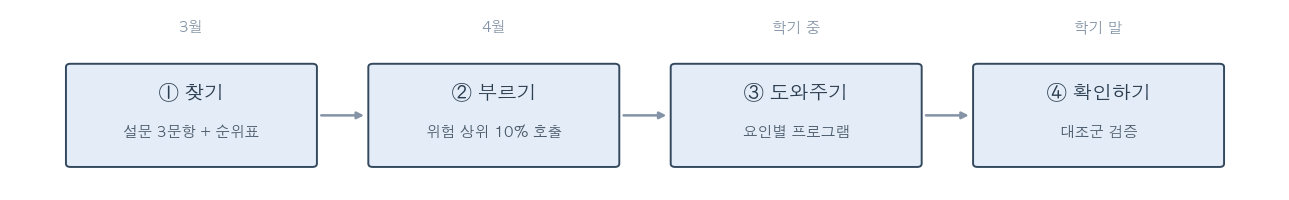

In [54]:
# 액션플랜 흐름 — 무엇을 하자는 것인가 (데이터 의존 없는 순수 도식)
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
plt.rcParams["font.family"] = "AppleGothic"; plt.rcParams["axes.unicode_minus"] = False

플랜 = [
    ("① 찾기",    "3월",    "설문 3문항 + 순위표"),
    ("② 부르기",  "4월",    "위험 상위 10% 호출"),
    ("③ 도와주기", "학기 중", "요인별 프로그램"),
    ("④ 확인하기", "학기 말", "대조군 검증"),
]

fig, ax = plt.subplots(figsize=(13, 2.1))
ax.set_xlim(0.4, 4.6); ax.set_ylim(0.18, 1); ax.axis("off")

for i, (verb, when, what) in enumerate(플랜):
    x = i + 1
    ax.text(x, 0.90, when, ha="center", fontsize=10.5, color="#8494A6")
    ax.add_patch(FancyBboxPatch((x - 0.40, 0.30), 0.80, 0.44, boxstyle="round,pad=0.015",
                                fc="#E3ECF7", ec="#34495E", lw=1.4, zorder=2))
    ax.text(x, 0.60, verb, ha="center", fontsize=14, fontweight="bold", color="#2C3E50", zorder=3)
    ax.text(x, 0.42, what, ha="center", fontsize=10.5, color="#4A5A6A", zorder=3)
    if i < 3:
        ax.annotate("", xy=(x + 0.58, 0.52), xytext=(x + 0.42, 0.52), zorder=5,
                    arrowprops=dict(arrowstyle="-|>", lw=1.8, color="#8494A6"))

plt.tight_layout(); plt.show()

①②③은 숫자가 없으면 계획이 못 된다 — §8에서 만든 OOF 확률과 원본 응답으로 직접 측정한다. ④만 실측이 없는데, 왜 없는지가 곧 ④의 내용이다.

### ① 찾기 실측 — 기기 없이 세 문항만으로 얼마나 가려내나

모델은 13개 피처를 썼다. 그런데 그 13개를 학교가 다 채울 수 있나를 따지면 갈린다. 수면·스트레스·운동·식단 같은 건 설문지로 받으면 되지만, **심박수·걸음수·칼로리 소모는 설문으로 못 받는다** — 학생 손목에 측정 기기를 채워야 나오는 값이다(§2에서 1000~14999로 범위가 잘려 있던 그 컬럼들). 전교생에게 기기를 채우는 건 예산도 동의도 전혀 다른 문제다.

그래서 물음이 좁혀진다: **기기 없이, 설문으로 받을 수 있는 것만으로 얼마나 되나?** §10이 답의 절반을 이미 줬다 — 세 피처(수면·스트레스·운동)만으로 0.944다. 하지만 그 0.944는 sleep을 50구간 이상으로 세밀하게 나눈 값이고, 설문에 적히는 수면시간은 현실적으로 0.5시간 단위다. 해상도를 설문 조건으로 낮추면 얼마가 남는지는 아직 안 쟀다.

설문 조건 그대로(수면 0.5h 반올림 + 스트레스 + 운동, held-out 반쪽 채점) 두 가지를 만든다: 선별력(balanced accuracy)과, 학교에 넘길 순위표. 기준선은 §9의 모델 0.9494다.

재기 전 예상: 0.5시간으로 뭉개면 셀이 거칠어지니 §10의 0.944보다는 떨어질 것이다. 다만 규칙 임계값이 6·7시간이라 0.5시간 눈금이 그 경계를 못 짚을 만큼 거칠진 않아서, 크게 잃지는 않을 것이다.

In [55]:
# ① 찾기 실측: 설문 3문항(0.5h 해상도)만으로 얼마나 가려내나
# §10 재검증과 같은 held-out 방식: A 반쪽으로 셀 확률 추정, B 반쪽에서 채점
import numpy as np
import pandas as pd
from sklearn.metrics import balanced_accuracy_score

oof = np.load('oof_proba.npy'); y = np.load('y_enc.npy')   # §8에서 저장한 OOF 확률
N = len(y)

tr = pd.read_csv('train.csv')
sleep_bin = (tr['sleep_duration'] * 2).round().fillna(-1).astype(int).astype(str)   # 0.5h 단위
cell3 = sleep_bin + '|' + tr['stress_level'].fillna('NA') + '|' + tr['physical_activity_level'].fillna('NA')

rng = np.random.RandomState(42)
idx = rng.permutation(N); A, B = idx[:N // 2], idx[N // 2:]
tab = pd.DataFrame({'cell': cell3.iloc[A].values, 'y': y[A]}).groupby('cell')['y'].value_counts().unstack(fill_value=0)
p_cell = tab.div(tab.sum(axis=1), axis=0)                                  # 셀별 클래스 확률
best = p_cell.div(np.bincount(y[A]) / len(A), axis=1).idxmax(axis=1)       # 확률/prior — 모델의 β와 같은 자

yB = y[B]; n_unB = int((yB == 2).sum())   # B 반쪽의 실제 unhealthy 수
# 셀 확률은 동점이 많다(256칸에 34만 명). 동점 순서는 무작위로 깨되, 여기서 배열을 한 번 만들어
# 아래 모든 셀이 같은 걸 쓴다 — 셀마다 새로 뽑으면 같은 값이 셀마다 달라진다(실제로 그랬다).
tie = np.random.RandomState(0).rand(len(B)) * 1e-9
pred_B = pd.Series(cell3.iloc[B].values).map(best).fillna(0).astype(int).values
print(f"설문 3문항(0.5h 해상도) held-out balanced accuracy: {balanced_accuracy_score(yB, pred_B):.4f}"
      f"   (§10 세밀 구간 0.944 / 13피처 모델 0.9494)")

# 학교에 넘길 배포물 — 세 문항 조합마다 위험 점수. 엑셀 VLOOKUP 한 칸이면 쓴다.
lookup = p_cell[2].sort_values(ascending=False)
print(f"\n=== 배포물: 위험 순위표 {len(lookup)}칸 (상위 5칸) ===")
print(f"{'잠(h)':>6} {'스트레스':>7} {'운동':>10} | 위험 점수")
for key, v in lookup.head(5).items():
    sl, st_, pa_ = key.split('|')
    print(f"{int(sl)/2:>6.1f} {st_:>7} {pa_:>10} | {v:.3f}")

설문 3문항(0.5h 해상도) held-out balanced accuracy: 0.9375   (§10 세밀 구간 0.944 / 13피처 모델 0.9494)

=== 배포물: 위험 순위표 256칸 (상위 5칸) ===
  잠(h)    스트레스         운동 | 위험 점수
   4.0    high         NA | 1.000
   3.0    high     active | 1.000
   3.0    high  sedentary | 1.000
   3.5    high         NA | 1.000
   3.5    high     active | 1.000


예상대로 §10의 0.944보다 떨어졌지만 크게는 아니다 — **0.9375**다. 설문 해상도에서는 이게 정직한 값이고, 모델 0.9494의 98.7%다. 규칙 임계값(6·7시간)이 0.5시간 눈금 위에 정확히 얹히는 덕이다.

**판단: 기기는 필요 없다.** 학교가 못 채우는 셋(심박·걸음수·칼로리)을 빼고 설문 세 문항만 남겨도 선별력의 98.7%가 남는다. 기본값은 설문이다 — 위 순위표 256칸을 엑셀에 붙이면 그날 바로 돌아간다. 기기를 채워서 실제로 얼마를 더 얻는지는 ②에서 호출 명단으로 측정한다. 선별력 1.2%p가 명단에서는 다른 크기로 나타나기 때문이다.

자기응답 오차(설문에 적는 수면시간 ≠ 실제 수면시간)는 어느 쪽에도 남는 전제라, 실데이터 검증(④) 전에는 확정이 아니다.

### 왜 세 문항인가 — 운동 문항이 하는 일

①이 문항을 셋 잡았는데, §10 규칙을 다시 보면 이상하다. `unhealthy = 잠<6 AND 스트레스 high`에 **운동이 없다.** 위험군만 찾을 거면 두 문항이면 되는 것 아닌가? 운동은 `fit = 잠>7 AND 스트레스 low AND 운동 active` 쪽에만 등장한다.

재기 전 예상: 운동을 빼도 unhealthy 커버리지는 그대로일 것이다(규칙에 없으니). 대신 fit 재현율이 떨어질 것이다(fit 규칙의 재료가 하나 빠지니).

In [56]:
# 왜 세 문항인가: 운동 문항을 빼면 뭘 잃나 — 2문항 vs 3문항 (① 과 같은 held-out 방식)
from sklearn.metrics import recall_score

cell2 = sleep_bin + '|' + tr['stress_level'].fillna('NA')      # 운동 문항 제외
names = ['at-risk', 'fit', 'unhealthy']

def survey_eval(cell, tag):
    t = pd.DataFrame({'cell': cell.iloc[A].values, 'y': y[A]}).groupby('cell')['y'].value_counts().unstack(fill_value=0)
    for k in [0, 1, 2]:
        if k not in t.columns:
            t[k] = 0
    pc = t[[0, 1, 2]].div(t[[0, 1, 2]].sum(axis=1), axis=0)
    bst = pc.div(np.bincount(y[A]) / len(A), axis=1).idxmax(axis=1)
    pr = pd.Series(cell.iloc[B].values).map(bst).fillna(0).astype(int).values
    rec = recall_score(yB, pr, average=None, labels=[0, 1, 2])
    sc = pd.Series(cell.iloc[B].values).map(pc[2]).fillna(0).values
    cov = np.cumsum(yB[np.argsort(-(sc + tie))] == 2) / n_unB * 100
    print(f"{tag:24s} BA {balanced_accuracy_score(yB, pr):.4f} | "
          + "  ".join(f"{names[k]} {rec[k]:.3f}" for k in [0, 1, 2])
          + f" | unhealthy 상위10% {cov[int(len(B) * 0.10) - 1]:.1f}%")
    return rec

r3 = survey_eval(cell3, "3문항 (잠+스트레스+운동)")
r2 = survey_eval(cell2, "2문항 (잠+스트레스)")
print("\n운동 문항을 더하면 클래스별 재현율:")
for k in [0, 1, 2]:
    print(f"  {names[k]:10s} {r2[k]:.3f} → {r3[k]:.3f}   ({r3[k] - r2[k]:+.3f})")

3문항 (잠+스트레스+운동)          BA 0.9375 | at-risk 0.893  fit 0.951  unhealthy 0.969 | unhealthy 상위10% 86.8%


2문항 (잠+스트레스)             BA 0.8870 | at-risk 0.755  fit 0.946  unhealthy 0.960 | unhealthy 상위10% 86.8%

운동 문항을 더하면 클래스별 재현율:
  at-risk    0.755 → 0.893   (+0.138)
  fit        0.946 → 0.951   (+0.005)
  unhealthy  0.960 → 0.969   (+0.008)


예상이 절반만 맞았다. unhealthy 쪽은 예상대로였다 — 그것도 예상보다 더 깨끗하게. 상위 10% 커버리지가 소수점까지 똑같고(86.8% → 86.8%) 위험군 재현율도 거의 안 움직인다(0.960 → 0.969). 규칙에 운동이 없으니 운동 문항은 위험군 순위에 *한 톨도* 못 보탠다.

**틀린 건 fit이었다.** fit 재현율은 0.946 → 0.951로 거의 그대로인데, 정작 무너진 쪽은 **at-risk다 — 0.755 → 0.893, 운동 문항이 +0.138을 되돌린다.** 규칙을 뒤집어 보면 이유가 나온다. 운동을 안 물으면 "잠>7 & 스트레스 low" 칸이 통째로 fit 판정을 받는다. 그런데 그 칸엔 운동을 안 해서 실제로는 at-risk인 학생이 섞여 있다. 운동 문항이 없으면 **잘 자고 스트레스 없는 학생을 전부 건강하다고 오판하고, 그 대가를 at-risk가 치른다.**

그래서 인사이트 3이 정확해진다. 운동 부족은 위험군을 만들지 않는다 — 위험군을 찾는 데는 두 문항이면 충분하다. 운동 문항이 하는 일은 *괜찮아 보이는 학생 중 안 괜찮은 애를 골라내는 것*이다. 그러니 운동 캠페인의 대상은 위험군 명단이 아니라 **잘 자고 스트레스도 낮은데 운동을 안 하는 학생** — fit 문턱에서 미끄러진 쪽이다. ③에서 이 자리를 다시 확인한다.

### ② 부르기 실측 — 순위표로 줄 세워 상위 k%를 부르면

①의 순위표는 학생마다 위험 점수를 준다. "위험한 순서로 부른다"를 숫자로 만들려면: 전교생을 그 점수 순으로 세우고, 상위 k%를 불렀을 때 실제 unhealthy 중 몇 %가 명단에 드는지(커버리지)를 측정하면 된다. 확률 임계값이 아니라 상위 k%로 끊는 이유는 학교 상담 여력이 고정이라서다 — 임계값 컷은 해마다 명단 크기가 출렁이지만 상위 k%는 예산 그대로다.

용어 주의: 여기서 "위험군"은 unhealthy(8.4%)를 가리킨다. 이 데이터의 at-risk(85.9%)는 이름과 달리 두 규칙에 안 걸린 나머지 전부가 담기는 기본값 다수 클래스라(§10), 전원 호출 대상이 될 수 없다.

같은 B 반쪽에서 네 줄을 나란히 측정한다: ①의 설문 순위, 13피처 모델 순위(기기를 채웠을 때), 완벽한 모델, 무작위 호출.

재기 전 예상. unhealthy 규칙(잠<6 & 스트레스 high)은 순도 98.4%였으니(§10) 명단 꼭대기는 그 규칙 셀 학생들로 채워질 것이다 — 초반 기울기는 이론 최대(무작위의 12배)에 붙고, 설문과 모델이 거의 겹칠 것이다. 반대로 규칙에 안 걸리는 unhealthy(graded 꼬리, §10의 안 걸린 나머지)를 가르는 건 셀이 거친 설문보다 모델이 나을 테니, 곡선이 꺾이는 중간 지대에서 벌어질 것이다. 기준선은 둘: 무작위 호출은 k% 불러 k%를 잡고(제비뽑기), 완벽한 모델은 unhealthy가 전체의 8.4%라 상위 8.4%에서 100%를 채운다.

β 보정 순위와 모델 순위의 커버리지 차이 최대 0.11%p → raw 확률 순위 사용
β=1 결정의 unhealthy 명단: 전체의 11.5%, 재현율 0.962

 호출 k% |    ① 설문 순위 |    모델 순위 | 설문 명단 중 진짜
     1 |      11.8% |    11.9% |       99.5%
     2 |      23.6% |    23.7% |       99.5%
     5 |      57.8% |    59.1% |       97.3%
   8.4 |      80.7% |    87.2% |       80.9%
    10 |      86.8% |    93.1% |       73.1%
    15 |      97.4% |    97.7% |       54.7%
    20 |      97.6% |    98.0% |       41.1%


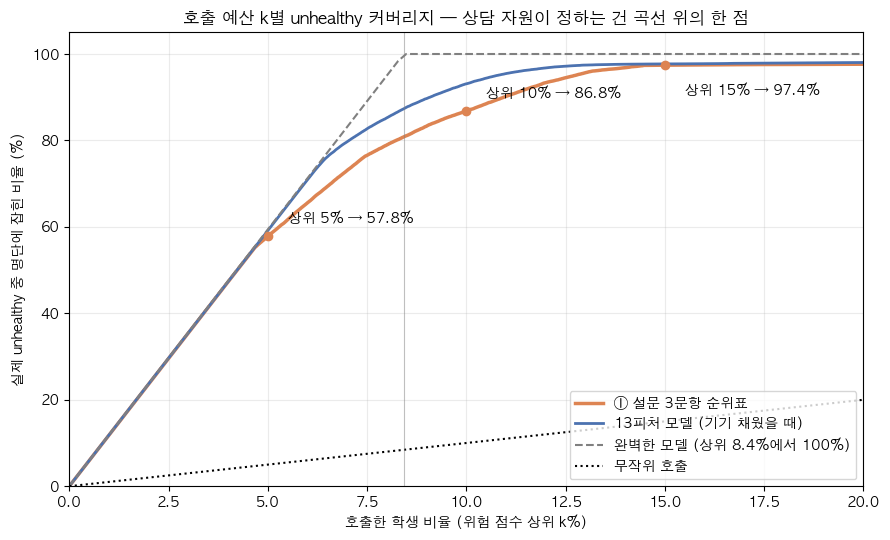

In [57]:
# ② 부르기: 호출 예산 k% → unhealthy 커버리지. ①의 설문 순위와 모델 순위를 같은 B 반쪽에서 비교.
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "AppleGothic"; plt.rcParams["axes.unicode_minus"] = False

prev = n_unB / len(B) * 100      # unhealthy 8.4% (n_unB는 ①에서 정의)

score_B = pd.Series(cell3.iloc[B].values).map(p_cell[2]).fillna(0).values   # ① 순위표가 주는 점수
rank_survey = B[np.argsort(-(score_B + tie))]                               # 설문 순위 (동점은 ①의 tie로)
rank_model = B[np.argsort(-oof[B][:, 2])]                                   # 모델 순위 (기기 채웠을 때)
cum_s = np.cumsum(y[rank_survey] == 2) / n_unB * 100
cum_m = np.cumsum(y[rank_model] == 2) / n_unB * 100
k_pct = np.arange(1, len(B) + 1) / len(B) * 100

# β 보정 확률로 줄 세워도 같은가 (한 클래스 순위라 사실상 같아야 정상)
prior = np.bincount(y) / N
adj = oof / prior; adj = adj / adj.sum(1, keepdims=True)
cum_b = np.cumsum(y[B[np.argsort(-adj[B][:, 2])]] == 2) / n_unB * 100
print(f"β 보정 순위와 모델 순위의 커버리지 차이 최대 {np.abs(cum_m - cum_b).max():.2f}%p → raw 확률 순위 사용")

# §9의 β=1 결정도 이 곡선 위의 한 점이다: 스스로 정한 명단 크기와 그때의 재현율
flag = adj.argmax(1) == 2
print(f"β=1 결정의 unhealthy 명단: 전체의 {flag.mean()*100:.1f}%, 재현율 {((y == 2) & flag).sum() / (y == 2).sum():.3f}\n")

print(f"{'호출 k%':>6} | {'① 설문 순위':>10} | {'모델 순위':>8} | 설문 명단 중 진짜")
for k in [1, 2, 5, 8.4, 10, 15, 20]:
    i = int(len(B) * k / 100)
    prec = (y[rank_survey[:i]] == 2).mean() * 100
    print(f"{k:>6} | {cum_s[i-1]:>9.1f}% | {cum_m[i-1]:>7.1f}% | {prec:>10.1f}%")

fig, ax = plt.subplots(figsize=(9, 5.5))
m = k_pct <= 20
ax.plot(k_pct[m], cum_s[m], color="#DD8452", lw=2.5, label="① 설문 3문항 순위표")
ax.plot(k_pct[m], cum_m[m], color="#4C72B0", lw=2, label="13피처 모델 (기기 채웠을 때)")
kk = np.linspace(0, 20, 100)
ax.plot(kk, np.minimum(kk / prev, 1) * 100, ls="--", color="gray", lw=1.5,
        label=f"완벽한 모델 (상위 {prev:.1f}%에서 100%)")
ax.plot(kk, kk, ls=":", color="black", lw=1.5, label="무작위 호출")
for k in [5, 10, 15]:
    i = int(len(B) * k / 100) - 1
    ax.scatter([k], [cum_s[i]], color="#DD8452", zorder=5)
    ax.annotate(f"상위 {k}% → {cum_s[i]:.1f}%", (k, cum_s[i]),
                xytext=(k + 0.5, cum_s[i] - 7 if k == 15 else cum_s[i] + 3), fontsize=10)
ax.axvline(prev, color="gray", lw=0.8, alpha=0.5)
ax.set_xlabel("호출한 학생 비율 (위험 점수 상위 k%)")
ax.set_ylabel("실제 unhealthy 중 명단에 잡힌 비율 (%)")
ax.set_title("호출 예산 k별 unhealthy 커버리지 — 상담 자원이 정하는 건 곡선 위의 한 점")
ax.legend(loc="lower right"); ax.set_xlim(0, 20); ax.set_ylim(0, 105); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

예상대로였다. 초반 기울기는 이론 최대에 붙어 설문과 모델이 상위 5%까지 바짝 붙고(57.8 vs 59.1%), 벌어지는 곳은 곡선이 꺾이는 중간 지대다 — 상위 10%에서 설문 86.8% vs 모델 93.1%로 6%p 차이다. 규칙 셀 밖에 흩어진 unhealthy(§10의 graded 꼬리)를 가르는 일은 셀이 거친 설문이 못 하고 모델이 한다. §9의 β=1 결정도 이 곡선 위의 한 점이었다.

**이 그림에서 판단한 것: 모델이 주는 건 정답이 아니라 가격표다.** 상담 여력이 전교생의 5%면 위험군의 58%, 10%면 87%, 15%면 97%가 잡힌다 — 어디서 끊을지는 모델이 못 정하고, 이 교환비를 보고 학교 예산이 정한다. 전교생 1,000명 학교로 옮기면: 100명을 부르면 위험군 84명 중 73명이 잡히고 명단의 27%는 헛걸음이다. 커버리지와 헛걸음의 교환이 숫자로 보이니, 이 결정은 데이터 과학자가 아니라 보건교사의 몫이 된다.

**기기값도 여기서 정해진다.** ①에서 선별력 차이는 1.2%p였는데 명단으로 옮기면 중간 예산 지대에서 6%p다 — 1,000명 학교로는 위험군 5명. 전교생 손목에 기기를 채워 5명을 더 찾을 것인가는 데이터가 아니라 학교가 답할 질문이다.

### ③ 도와주기 실측 — 명단의 구성이 곧 프로그램 규모다

부른 다음은 "무엇을 해주나"다. §10 규칙이 요인을 준다: 잠<6h면 수면 위생 프로그램(취침 루틴·스크린타임), 스트레스 high면 상담. 남는 질문은 규모 — 프로그램이 몇 개고 각각 몇 명인가. 명단은 ①의 설문 순위표로 세우고(학교가 실제로 쓰는 것), 모델 순위도 나란히 놓아 구성이 갈리는지 본다.

재기 전 예상. unhealthy 규칙이 수면×스트레스 조합이니 명단 꼭대기는 그 묶음으로 채워져 있을 것이다. 반대로 운동은 fit 규칙에만 등장하니(바로 위 실측), 명단의 저활동 비율은 모집단 기저율을 넘지 않을 것이다.

In [58]:
# ③ 도와주기: 호출 명단의 요인 구성 — 프로그램이 몇 개고 각각 몇 명인가.
# 명단은 ①의 설문 순위표로 세운다(학교가 실제로 쓰는 것). 모델 순위도 나란히 놓아 구성이 갈리는지 본다.
# 명단은 ②에서 세운 순위를 그대로 쓴다 (여기서 다시 만들면 동점 처리가 달라져 ②의 곡선과 어긋난다)
sleep_lack = tr['sleep_duration'] < 6
stress_hi = tr['stress_level'] == 'high'
sedentary = tr['physical_activity_level'] == 'sedentary'

for k in [5, 10]:
    n = int(len(B) * k / 100)
    cs, cm = rank_survey[:n], rank_model[:n]
    print(f"=== 상위 {k}% 명단 ({n:,}명) — 설문 순위 / 모델 순위 / 전교생 기저율 ===")
    for name, f in [("잠<6h → 수면 프로그램", sleep_lack),
                    ("스트레스 high → 상담", stress_hi),
                    ("저활동 → 위험군 개입 아님", sedentary)]:
        print(f"  {name:<24s}: {f.iloc[cs].mean()*100:5.1f}% / {f.iloc[cm].mean()*100:5.1f}% / 기저 {f.mean()*100:4.1f}%")
    # 겹치지 않게 쪼갠다 — 이게 곧 교실 배정이다
    both = (sleep_lack & stress_hi).iloc[cs].mean() * 100
    both_m = (sleep_lack & stress_hi).iloc[cm].mean() * 100
    only_sleep = (sleep_lack & ~stress_hi).iloc[cs].mean() * 100
    only_stress = (~sleep_lack & stress_hi).iloc[cs].mean() * 100
    neither = (~(sleep_lack | stress_hi)).iloc[cs].mean() * 100
    print(f"  {'수면×스트레스 둘 다 (묶음)':<22s}: {both:5.1f}% / {both_m:5.1f}% / 기저 {(sleep_lack & stress_hi).mean()*100:4.1f}%")
    print(f"  명단 쪼개기(설문 순위): 수면만 {only_sleep:.1f}% + 둘 다 {both:.1f}% "
          f"+ 상담만 {only_stress:.1f}% + 해당없음 {neither:.2f}%\n")

=== 상위 5% 명단 (17,252명) — 설문 순위 / 모델 순위 / 전교생 기저율 ===
  잠<6h → 수면 프로그램          :  97.7% / 100.0% / 기저 19.5%
  스트레스 high → 상담          : 100.0% / 100.0% / 기저 25.8%
  저활동 → 위험군 개입 아님         :  28.0% /  31.0% / 기저 31.8%
  수면×스트레스 둘 다 (묶음)      :  97.6% / 100.0% / 기저  6.4%
  명단 쪼개기(설문 순위): 수면만 0.0% + 둘 다 97.6% + 상담만 2.3% + 해당없음 0.00%

=== 상위 10% 명단 (34,504명) — 설문 순위 / 모델 순위 / 전교생 기저율 ===
  잠<6h → 수면 프로그램          :  80.3% /  82.4% / 기저 19.5%
  스트레스 high → 상담          :  83.9% /  81.2% / 기저 25.8%
  저활동 → 위험군 개입 아님         :  28.0% /  30.5% / 기저 31.8%
  수면×스트레스 둘 다 (묶음)      :  64.2% /  64.1% / 기저  6.4%
  명단 쪼개기(설문 순위): 수면만 16.1% + 둘 다 64.2% + 상담만 19.7% + 해당없음 0.00%



예상이 맞았다. 상위 5% 명단은 97.6%가 "잠<6 & 스트레스 high" 둘 다다(모델 순위로는 100%) — 꼭대기는 거의 균질해서, 호출 예산이 빡빡한 학교일수록 개입이 오히려 단순하다. 수면과 스트레스를 같이 다루는 프로그램 하나로 명단 전원이 커버된다.

상위 10%로 넓히면 구성이 갈라진다. 그리고 설문 순위와 모델 순위가 만드는 명단은 사실상 같다(묶음 64.2 vs 64.1%) — ①에서 기기를 포기하고 설문으로 내려앉아도 ③의 배정은 안 바뀐다는 뜻이다.

**저활동은 명단에서 28.0%로 기저율(31.8%)보다 오히려 낮다.** 바로 위에서 측정한 대로 운동 부족은 위험군을 만들지 않는다. 그러니 운동 프로그램은 위험군 구출용이 아니라 **fit 문턱에서 미끄러진 학생**(잘 자고 스트레스도 낮은데 운동을 안 하는 쪽) 대상 예방 캠페인 자리에 놓는 게 데이터와 맞는다.

전교생 1,000명 학교, 상위 10%(100명) 호출 기준으로 교실을 잡으면:

| 대상 | 개입 | 인원 |
|---|---|---|
| 잠 부족 + 고스트레스 | 수면 프로그램과 상담 양쪽 (최고위험, 우선) | 64명 |
| 잠 부족만 | 수면 프로그램 | 16명 |
| 고스트레스만 | 상담 | 20명 |
| 둘 다 아님 | — | 0명 (라우팅 사각 없음) |

**프로그램은 둘이다** — 수면 프로그램 80명(64+16), 상담 84명(64+20). 겹치는 64명이 양쪽에 들어간다. 운동 캠페인은 이 명단이 아니라 전교 대상으로 따로 돈다.

### ④ 확인하기 — 개입은 인과를 가정하므로, 검증을 통과한 것만

①~③은 상관만으로 성립한다 — 누구를 찾고, 부르고, 어느 프로그램에 배정할지는 예측이 맞기만 하면 된다. 그러나 개입이 효과를 내는가("재우면 나아지는가")는 인과 주장이라 별도 검증이 필요하다.

- 전면 시행 대신 단계적 롤아웃(stepped-wedge)이나 개입군 vs 대조군으로 간다. 한 번에 다 하면 좋아진 게 개입 덕인지 계절 탓인지 못 가린다.
- **결과는 설문 3문항이 아닌 것으로 측정한다.** 위험 플래그가 "잠<6 & 스트레스 high"로 정의되는데 결과지표까지 같은 3문항이면, 수면 프로그램이 응답을 바꾸는 순간 인과가 없어도 플래그는 내려간다 — 효과가 있든 없든 항상 성공하는 설계다. 결과는 설문 밖 독립 지표로 측정한다(보건실 이용 횟수, 체력검사, 결석률 같은 것). 개입군이 대조군보다 내려가되, p값만이 아니라 효과 크기가 실질적인 요인만 다음 학기에 남긴다 — §2에서 배운 유의미≠중요를 자기 검증에도 적용한다.

**실패 모드 셋.**
- **낙인:** 위험 플래그가 학생 라벨로 작동하면 역효과다. 플래그는 자원 배분 내부용으로만 두고, 학생에겐 개입만 노출한다.
- **드리프트:** 생활 패턴이 바뀌면 규칙이 낡는다. 매년 설문으로 재검증하고, 임계값(잠 6h·7h)이 흔들리면 그때 모델을 다시 부른다.
- **상관의 함정:** ④를 건너뛰고 ③의 배정을 인과로 믿으면, 이 노트북이 내내 경계한 오류를 현장에서 반복하는 것이다.

이 대회의 최종 산출물 — **설문 3문항과 256칸 위험 순위표, 호출 예산별 커버리지 곡선, 규모가 붙은 프로그램 표, 그리고 검증 설계.** 

### 액션플랜 4단계 — 실측이 받쳐주는 곳, 그리고 가정이 시작되는 곳

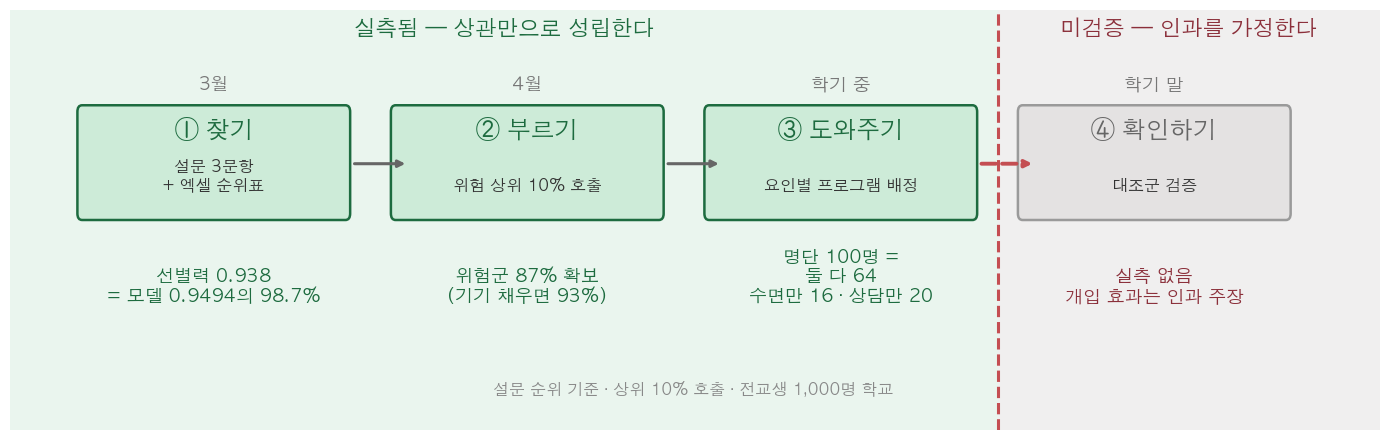

In [59]:
# 액션플랜 종합: 4동사 타임라인 + 근거 층 경계선. (제목은 위 마크다운)
# 숫자는 전부 앞 셀 변수에서 실계산한다 (하드코딩 없음).
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
plt.rcParams["font.family"] = "AppleGothic"; plt.rcParams["axes.unicode_minus"] = False

ba_survey = balanced_accuracy_score(yB, pred_B)                # ① 설문 3문항 선별력
ba_model = balanced_accuracy_score(y, adj.argmax(1))           # 비교용: 모델 OOF, β=1 (§9)
i10 = int(len(B) * 0.10)
cov_s, cov_m = cum_s[i10 - 1], cum_m[i10 - 1]                  # ② 상위 10% 커버리지 (설문 / 모델)

called = rank_survey[:i10]                                     # ③ 설문 순위 상위 10% 명단
p_both = (sleep_lack & stress_hi).iloc[called].mean() * 100    # 겹치지 않게 쪼갠다 → 합이 100
p_sleep_only = (sleep_lack & ~stress_hi).iloc[called].mean() * 100
p_stress_only = (~sleep_lack & stress_hi).iloc[called].mean() * 100

steps = [
    ("① 찾기",    "3월",     "설문 3문항\n+ 엑셀 순위표",
     f"선별력 {ba_survey:.3f}\n= 모델 {ba_model:.4f}의 {ba_survey / ba_model * 100:.1f}%"),
    ("② 부르기",  "4월",     "위험 상위 10% 호출",
     f"위험군 {cov_s:.0f}% 확보\n(기기 채우면 {cov_m:.0f}%)"),
    ("③ 도와주기", "학기 중",  "요인별 프로그램 배정",
     f"명단 100명 =\n둘 다 {p_both:.0f}\n수면만 {p_sleep_only:.0f} · 상담만 {p_stress_only:.0f}"),
    ("④ 확인하기", "학기 말",  "대조군 검증",
     "실측 없음\n개입 효과는 인과 주장"),
]

fig, ax = plt.subplots(figsize=(14, 4.5))
ax.set_xlim(0.35, 4.72); ax.set_ylim(0.03, 1); ax.axis("off")

# 근거 층: 초록 = 상관으로 성립(실측됨) / 회색 = 인과 가정(미검증)
ax.axvspan(0.35, 3.5, color="#EAF5EE", zorder=0)
ax.axvspan(3.5, 4.72, color="#F0EFEF", zorder=0)
ax.axvline(3.5, color="#C44E52", ls="--", lw=2.2, zorder=4)
ax.text(1.925, 0.94, "실측됨 — 상관만으로 성립한다", ha="center", fontsize=15.5,
        fontweight="bold", color="#1d6b3f")
ax.text(4.11, 0.94, "미검증 — 인과를 가정한다", ha="center", fontsize=15.5,
        fontweight="bold", color="#8B2F3A")

for i, (verb, when, what, ev) in enumerate(steps):
    x, measured = i + 1, i < 3
    ax.text(x, 0.815, when, ha="center", fontsize=13, color="#777")
    ax.add_patch(FancyBboxPatch((x - 0.42, 0.53), 0.84, 0.235, boxstyle="round,pad=0.015",
                                fc="#CDEBD8" if measured else "#E4E2E2",
                                ec="#1d6b3f" if measured else "#9A9A9A", lw=1.8, zorder=2))
    ax.text(x, 0.705, verb, ha="center", fontsize=17, fontweight="bold",
            color="#1d6b3f" if measured else "#666", zorder=3)
    ax.text(x, 0.583, what, ha="center", fontsize=11.5, color="#333", zorder=3)
    ax.text(x, 0.325, ev, ha="center", fontsize=13,
            color="#1d6b3f" if measured else "#8B2F3A",
            fontweight="bold" if measured else "normal")
    if i < 3:
        cross = (i == 2)   # ③→④만 경계선을 넘는다
        ax.annotate("", xy=(x + 0.62, 0.645), xytext=(x + 0.44, 0.645), zorder=5,
                    arrowprops=dict(arrowstyle="-|>", lw=2.8 if cross else 2.2,
                                    color="#C44E52" if cross else "#666",
                                    ls="--" if cross else "-"))

ax.text(2.53, 0.11, "설문 순위 기준 · 상위 10% 호출 · 전교생 1,000명 학교",
        ha="center", fontsize=11.5, color="#888")
plt.tight_layout(); plt.show()

**이 그림에서 판단한 것: 색이 곧 이 플랜의 구조다.** ①②③은 초록 — 예측이 맞기만 하면 성립하니 위에서 측정한 숫자가 그대로 근거로 붙는다. ④만 회색이고 붙일 숫자가 없다. "잠<6이면 unhealthy가 많다"는 측정했지만 "재우면 건강해진다"는 이 데이터로 측정 못하기 때문이다.

### 그래서 학교에 넘길 수 있나

넘길 수 있는 건 ③까지다. 찾기·부르기·도와주기는 예측이 맞기만 하면 성립하니 위에서 측정한 숫자가 그대로 근거가 된다. ④ 확인하기는 넘길 수 없다 — 개입이 효과가 있다는 건 이 데이터로 측정한 적이 없기 때문이다. 대조군 검증이 끝난 뒤에야 넘어간다.

0.949짜리 모델을 만들었지만, 학교에 넘기는 건 설문지 세 줄이다.
